#**Projet 2 : Prédiction du risque d’accident de vélo**
**France 2005-2023, Machine Learning & Classification binaire**

### ***Realisé par :***

- Cedric enzo Kouokam kamhoua

**Source :** https://www.data.gouv.fr/datasets/accidents-de-velo (janvier 2026)  
**Schéma des variables :** https://opendata.koumoul.com/datasets/accidents-velos  
**Variable cible analysée :** `grav` -> recodée en binaire, `1 = grave` (tué ou blessé hospitalisé) / `0 = non grave`


#### Sommaire

1. Installation & Imports
2. Chargement & Vue d'ensemble
3. Nettoyage des données

***EDA :***


4. Variable cible : `grav`
5. Analyse temporelle
   - Évolution annuelle
   - Volume vs gravité selon l'heure
   - Analyse mensuelle, saisonnière et hebdomadaire
6. Gravité selon les conditions
   - Luminosité, météo et état de la chaussée
   - Agglomération, intersections et géographie
7. Profil des victimes
   - Sexe
   - Âge et tranches d'âge
8. Corrélations & tests statistiques
9. Feature engineering

10. **Modélisation ML**
    - Split train / test
    - Normalisation
    - Gestion du déséquilibre de classes
    - Régression Logistique
    - Random Forest
    - XGBoost
    - SVM
11. Évaluation & comparaison des modèles
12. Interprétation & limites
    - Feature importance
    - Limites & biais
13. Pistes d'améliorations
14. Choix méthodologiques
15. Conclusion


## **1. Installation & Imports**

In [ ]:
# dé commenter les install si besoin
#!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.impute import SimpleImputer

# Machine Learning
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score, accuracy_score,
    precision_recall_curve
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.experimental import enable_halving_search_cv

#SVM
from sklearn.svm import SVC
from scipy.stats import loguniform
from sklearn.metrics import ConfusionMatrixDisplay
import shap
import time

# utilisé en test
from sklearn.preprocessing import label_binarize
from sklearn.metrics import ConfusionMatrixDisplay

# Style global
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

print('Imports OK')

Imports OK


## **2. Chargement & Vue d'ensemble**

In [ ]:
URL = 'https://www.data.gouv.fr/fr/datasets/r/4c75d6c0-c927-48ca-92db-5bcce9f17ae7'
df = pd.read_csv(URL, sep=',', encoding='utf-8', low_memory=False)

print(f'Shape : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'\nTypes de colonnes :')
print(df.dtypes.value_counts())
df.head()

Shape : 80,022 lignes × 39 colonnes

Types de colonnes :
object     15
float64    15
int64       9
Name: count, dtype: int64


,Num_Acc,date,an,mois,jour,hrmn,dep,com,lat,long,agg,int,col,lum,atm,catr,circ,nbv,prof,plan,lartpc,larrout,surf,infra,situ,grav,sexe,age,trajet,secuexist,equipement,obs,obsm,choc,manv,vehiculeid,typevehicules,manoeuvehicules,numVehicules
0,200500000030,2005-01-13,2005,janvier,jeudi,19:45,62,62331,50.3,2.84,2,1,3.00,5,1.00,3,2.00,00,-1.00,1.00,000,050,1.00,0.00,1.00,4,1,58.00,5.00,3,0,0.00,2.00,8.00,11.00,200500000030B02,18,17,1.00
1,200500000034,2005-01-19,2005,janvier,mercredi,10:45,62,62022,0,0,1,1,1.00,1,7.00,3,2.00,00,1.00,3.00,000,050,1.00,0.00,1.00,3,1,20.00,5.00,3,0,0.00,2.00,1.00,1.00,200500000034B02,10,15,1.00
2,200500000078,2005-01-26,2005,janvier,mercredi,13:15,02,02173,0,0,1,9,3.00,1,1.00,3,2.00,02,2.00,1.00,000,000,1.00,0.00,1.00,4,1,71.00,5.00,2,2,0.00,2.00,1.00,1.00,200500000078B02,7,15,1.00
3,200500000093,2005-01-03,2005,janvier,lundi,13:30,02,02810,49.255,3.094,2,1,1.00,1,1.00,3,2.00,00,1.00,2.00,000,052,1.00,0.00,1.00,3,2,51.00,4.00,3,0,0.00,2.00,3.00,21.00,200500000093B02,7,21,1.00
4,200500000170,2005-01-29,2005,janvier,samedi,18:30,76,76196,0,0,1,1,2.00,3,1.00,3,2.00,02,1.00,1.00,000,050,1.00,0.00,1.00,4,1,74.00,5.00,1,9,0.00,2.00,4.00,2.00,200500000170A01,10,2,1.00


In [ ]:
# Résumé statistique des colonnes numériques
print('STATISTIQUES DESCRIPTIVES : COLONNES NUMÉRIQUES')
display(df.describe().round(2))

print('STATISTIQUES DESCRIPTIVES : COLONNES CATÉGORIELLES')
display(df.describe(include=['object']).T)

STATISTIQUES DESCRIPTIVES : COLONNES NUMÉRIQUES


,Num_Acc,an,agg,int,col,lum,atm,catr,circ,prof,plan,surf,infra,situ,grav,sexe,age,trajet,secuexist,obs,obsm,choc,manv,numVehicules
count,80022.00,80022.00,80022.00,80022.00,80018.00,80022.00,80019.00,80022.00,79879.00,79845.00,79822.00,79848.00,79486.00,79528.00,80022.00,80022.00,79995.00,80019.00,80022.00,79996.00,79981.00,80010.00,80006.00,68836.00
mean,201282668992.82,2012.83,1.81,2.13,3.49,1.53,1.47,3.79,1.68,1.11,1.07,1.11,0.53,1.40,3.40,1.24,40.60,3.53,2.09,0.41,1.64,2.84,5.38,1.03
std,520360929.14,5.20,0.39,1.82,1.78,1.27,1.54,1.03,0.88,0.74,0.83,0.81,1.61,1.28,0.85,0.43,56.52,2.54,0.86,2.13,1.16,2.79,7.06,0.18
min,200500000030.00,2005.00,1.00,0.00,-1.00,-1.00,-1.00,1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,1.00,-1.00,0.00,-1.00,-1.00,-1.00,-1.00,1.00
25%,200800058805.75,2008.00,2.00,1.00,3.00,1.00,1.00,3.00,1.00,1.00,1.00,1.00,0.00,1.00,3.00,1.00,21.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00
50%,201200061436.00,2012.00,2.00,1.00,3.00,1.00,1.00,4.00,2.00,1.00,1.00,1.00,0.00,1.00,4.00,1.00,37.00,5.00,2.00,0.00,2.00,1.00,1.00,1.00
75%,201700021271.00,2017.00,2.00,3.00,5.00,1.00,1.00,4.00,2.00,1.00,1.00,1.00,0.00,1.00,4.00,1.00,55.00,5.00,3.00,0.00,2.00,4.00,11.00,1.00
max,202300054757.00,2023.00,2.00,9.00,7.00,5.00,9.00,9.00,4.00,4.00,4.00,9.00,9.00,8.00,4.00,2.00,2023.00,9.00,3.00,17.00,9.00,9.00,26.00,5.00


STATISTIQUES DESCRIPTIVES : COLONNES CATÉGORIELLES


,count,unique,top,freq
date,80022,6891,2006-09-26,40
mois,80022,12,juin,9025
jour,80022,7,mercredi,13397
hrmn,80022,1244,17:00,1163
dep,80022,113,75,13853
com,80022,11637,67482,1394
lat,80022,31590,0,41732
long,79754,33250,0,42439
nbv,79825,32,02,37519
lartpc,63788,221,000,58595


**Observations sur les statistiques descriptives :**
- `an` : min=2005, max=2023 -> dataset couvrant **19 ans**
- `age` : max=2023 -> **valeur aberrante** évidente (une année saisie à la place d'un âge)
- `grav` : médiane=4 -> majorité de blessés légers, confirme le **déséquilibre de classes** anticipé
- Présence de **`-1`** dans de nombreuses colonnes : -1 est très souvent utilisé comme valeur technique pour ‘non renseigné. Ces valeurs devront être remplacées par `NaN` avant toute modélisation.
- `larrout` (largeur de chaussée) et `nbv` (nombre de voies) présentent des **valeurs aberrantes** physiquement impossibles (ex : chaussée de 990 m, 90 voies)

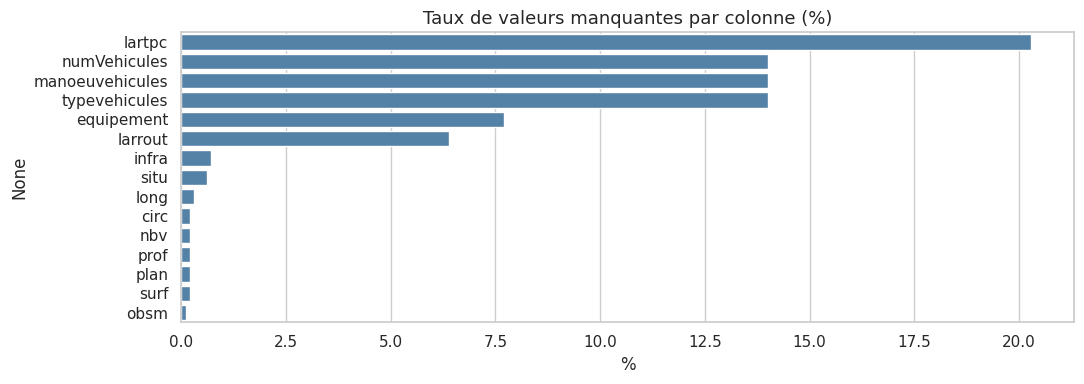

Valeurs manquantes (%) :
lartpc            20.30
numVehicules      14.00
manoeuvehicules   14.00
typevehicules     14.00
equipement         7.70
larrout            6.40
infra              0.70
situ               0.60
long               0.30
circ               0.20
nbv                0.20
prof               0.20
plan               0.20
surf               0.20
obsm               0.10

Total de doublons : 41


In [ ]:
# Valeurs manquantes
missing = (df.isnull().sum() / len(df) * 100).round(1)
missing = missing[missing > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(x=missing.values, y=missing.index, color='steelblue', ax=ax)
ax.set_title('Taux de valeurs manquantes par colonne (%)', fontsize=13)
ax.set_xlabel('%')
plt.tight_layout()
plt.show()

print('Valeurs manquantes (%) :')
print(missing.to_string())
print(f'\nTotal de doublons : {df.duplicated().sum()}')

In [ ]:
# Détection des outliers sur les colonnes numériques continues
cols_num = ['age', 'nbv', 'larrout', 'lartpc']

print(f"{'Colonne':<12} {'Q1':>6} {'Q3':>6} {'Borne inf':>10} {'Borne sup':>10} {'Outliers':>10} {'%':>6}")
print('-' * 65)

for col in cols_num:
    if col not in df.columns:
        continue
    s = pd.to_numeric(df[col], errors='coerce').dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((s < lo) | (s > hi)).sum()
    print(f"{col:<12} {Q1:>6.0f} {Q3:>6.0f} {lo:>10.0f} {hi:>10.0f} {n_out:>10} {n_out/len(df)*100:>6.1f}%")

Colonne          Q1     Q3  Borne inf  Borne sup   Outliers      %
-----------------------------------------------------------------
age              21     55        -30        106         60    0.1%
nbv               1      2         -0          4       6781    8.5%
larrout           0     70       -105        175       1130    1.4%
lartpc            0      0          0          0       5175    6.5%


On a des valeurs manquantes sur 15 colonnes. Les plus problématiques sont `lartpc` (20%)
et les trois colonnes liées au véhicule adverse `numVehicules`, `manoeuvehicules` et
`typevehicules` (14% chacune) qu'on va traiter ensemble en section 3. On a aussi 41
doublons et quelques valeurs aberrantes sur `nbv` (8.5%) qu'on va nettoyer.

## **3. Nettoyage des données**

In [ ]:
print(f'Shape initiale : {df.shape}')

# 1. Suppression des doublons
df = df.drop_duplicates()
print(f'Après suppression des doublons : {df.shape}')

# 2. Remplacement des -1 par NaN
cols_avec_moins1 = [
    'col', 'lum', 'atm', 'circ', 'prof', 'plan', 'surf', 'infra',
    'situ', 'obs', 'obsm', 'choc', 'manv', 'sexe', 'trajet', 'int', 'catr'
]
for col in cols_avec_moins1:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').replace(-1, np.nan)

# Suppression de la seule ligne grav=-1 (cible inconnue, inutilisable)
df = df[df['grav'] != -1].copy()
print('Valeurs -1 remplacées par NaN')

Shape initiale : (80022, 39)
Après suppression des doublons : (79981, 39)
Valeurs -1 remplacées par NaN


In [ ]:
# 3. Correction des types
# lat/long stockés avec virgule décimale dans certaines versions du CSV
df['lat']     = pd.to_numeric(df['lat'].astype(str).str.replace(',', '.'), errors='coerce')
df['long']    = pd.to_numeric(df['long'].astype(str).str.replace(',', '.'), errors='coerce')
df['lartpc']  = pd.to_numeric(df['lartpc'].astype(str).str.replace(',', '.'), errors='coerce')
df['larrout'] = pd.to_numeric(df['larrout'].astype(str).str.replace(',', '.'), errors='coerce')
df['nbv']     = pd.to_numeric(df['nbv'], errors='coerce')
df['date']    = pd.to_datetime(df['date'], errors='coerce')

# 4. Valeurs aberrantes
# Âge > 100 ans : probablement une année saisie à la place de l'âge (ex: 2018)
n_age_aberrant = (df['age'] > 100).sum()
df.loc[df['age'] > 100, 'age'] = np.nan
print(f'Âges > 100 ans mis à NaN : {n_age_aberrant} lignes')

# Largeur de chaussée > 30m : physiquement impossible (max réaliste ~20m pour une 2x3 voies)
df['larrout'] = df['larrout'].where(df['larrout'] <= 30, np.nan)

# Nombre de voies > 10 : aberrant
df['nbv'] = df['nbv'].where(df['nbv'] <= 10, np.nan)

# Largeur du TPC plafonner à 20m (largeur max réaliste d'un terre-plein)
df["lartpc"] = df["lartpc"].clip(upper=20)

# Remplacer les -1 par Nan
df["larrout"] = df["larrout"].replace(-1, np.nan)
df["nbv"] = df["nbv"].replace(-1, np.nan)

print(f'Shape après nettoyage complet : {df.shape}')

# df filtré après 2018
df = df[df['date'].dt.year >= 2018].copy()
print(f"Après filtre 2018+ : {df.shape}")

Âges > 100 ans mis à NaN : 61 lignes
Shape après nettoyage complet : (79980, 39)
Après filtre 2018+ : (16625, 39)


On trouve ici une rupture nette en 2018 de la remontée de data (2 600/an vs 4 500–5 400/an avant).

Cause suposée : refonte du protocole de collecte BAAC vers mi-2017 (plus de sécu/contrôle et nouvelle methodo statistique, [source](https://www.onisr.securite-routiere.gouv.fr/outils-statistiques/methodologies-statistiques))

-> On garde 2005–2023 pour l'EDA descriptive, mais on filtrera sur 2018+ pour la modélisation.

In [ ]:
# 5. Analyse de l'informativeness des valeurs manquantes
# Avant d'imputer ou supprimer, on vérifie si les NaN sont distribués uniformément selon la gravité.
# Si les NaN sont concentrés dans une classe -> ils sont informatifs
# -> on crée une variable indicatrice is_missing plutôt que d'imputer naïvement

# Création temporaire de la cible binaire pour ce diagnostic
grav_bin_temp = df['grav'].apply(lambda x: 1 if x in [2, 3] else 0)

cols_check = [c for c in ['lartpc', 'manoeuvehicules', 'typevehicules',
                           'numVehicules', 'equipement', 'larrout'] if c in df.columns]

print(f"{'Colonne':<22} {'% NaN total':>12} {'% NaN non grave':>16} {'% NaN grave':>12} {'Informatif ?':>14}")
print('-' * 80)

for col in cols_check:
    df['_is_nan'] = df[col].isnull().astype(int)
    pct_total = df['_is_nan'].mean() * 100
    pct_0 = df[grav_bin_temp == 0]['_is_nan'].mean() * 100
    pct_1 = df[grav_bin_temp == 1]['_is_nan'].mean() * 100
    info = 'OUI' if abs(pct_0 - pct_1) > 5 else 'NON'
    print(f"{col:<22} {pct_total:>11.1f}% {pct_0:>15.1f}% {pct_1:>11.1f}% {info:>14}")

df.drop(columns=['_is_nan'], inplace=True)

Colonne                 % NaN total  % NaN non grave  % NaN grave   Informatif ?
--------------------------------------------------------------------------------
lartpc                        93.1%            91.2%        96.2%            NON
manoeuvehicules               16.9%            16.6%        17.3%            NON
typevehicules                 16.8%            16.6%        17.3%            NON
numVehicules                  16.8%            16.6%        17.3%            NON
equipement                    36.9%            38.7%        34.0%            NON
larrout                       85.9%            87.7%        83.0%            NON


On démarre avec 80 022 lignes. Première chose, on supprime les 41 doublons, ça nous
amène à 79 981 lignes. Ensuite on remplace tous les -1 par des NaN = "non renseigné", si on le laisse tel
quel ça va fausser tous nos calculs.

On corrige aussi quelques problèmes de types, les coordonnées GPS et largeurs de voie
sont stockées avec une virgule au lieu d'un point dans certaines versions du CSV,
pandas ne les reconnaît pas comme des nombres sans cette correction.

Sur les outliers on a trouvé 61 âges supérieurs à 100 ans, très probablement des années
saisies à la place de l'âge genre 2018, on les passe à NaN. On plafonne aussi les
largeurs de chaussée à 30m et le nombre de voies à 10 (notre théorie -> physiquement
ça ne peut pas dépasser ces valeurs).

On filtre ensuite sur 2018+ ce qui réduit le dataset à 16 625 lignes. En bref avant
2018 on avait entre 4 500 et 5 400 accidents par an, après on tombe à 2 600, c'est un
changement de méthode de collecte pas une vraie baisse, garder les deux périodes aurait
biaisé les modèles.

Dernière étape, avant d'imputer les NaN on vérifie s'ils sont informatifs, c'est à
dire si leur absence est concentrée dans une classe plutôt que l'autre. Si c'est le
cas ça vaut le coup de créer une variable indicatrice plutôt que d'imputer bêtement.
Résultat : aucune colonne n'est vraiment informative ici, les NaN sont répartis de
façon homogène entre graves et non graves.

À noter que tous les NaN ne sont pas de même nature :
- Les `-1` remplacés par NaN sont des valeurs **non renseignées** : l'information
  existe mais n'a pas été saisie
- Les NaN sur les colonnes véhicule adverse (`manoeuvehicules`, `typevehicules`,
  `numVehicules`) sont **non applicables** : il n'y avait tout simplement pas de tiers
  impliqué. C'est pourquoi on a créé `tiers_present` plutôt que d'imputer ces colonnes.
- Certains NaN sur `larrout` ou `lartpc` sont potentiellement **non définis** :
  la largeur de chaussée n'est pas mesurable sur certains types de voies non classifiées.

On impute par la médiane pour `larrout` et `equipement` car leurs distributions sont
asymétriques, la moyenne serait tirée vers le haut par les outliers résiduels. Une
imputation par KNN aurait mieux préservé les relations entre variables, mais avec
131 features le coût computationnel n'était pas justifié pour des taux de NaN inférieurs
à 10%. On supprime carrément `lartpc` qui a plus de 90% de NaN sur le dataset filtré.

## **4. Variable cible : `grav`**

grav
4    9014
3    5459
1    1237
2     915
Name: count, dtype: int64

Répartition (%) :
grav
4   54.20
3   32.80
1    7.40
2    5.50
Name: proportion, dtype: float64


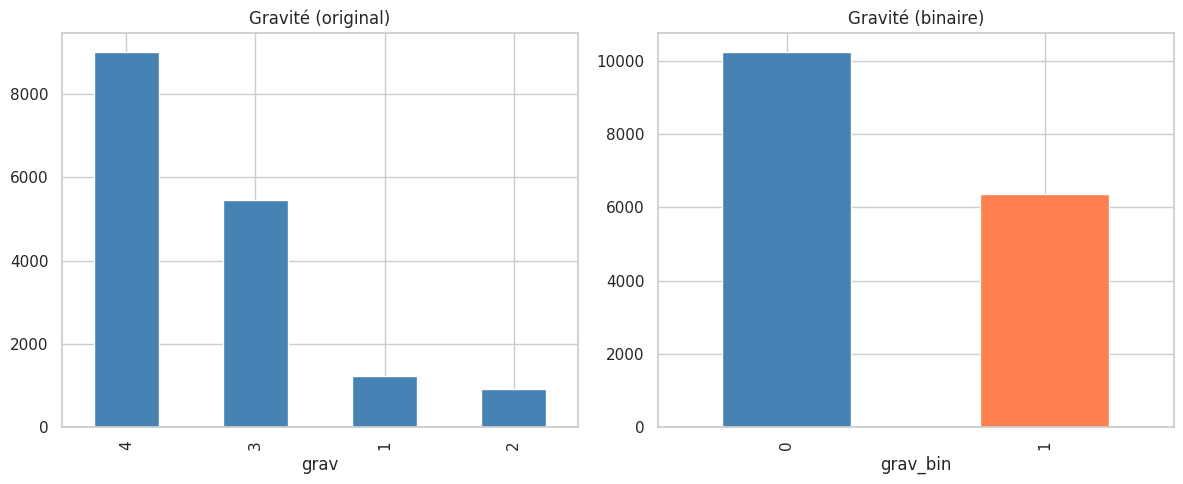

In [ ]:
col_cible = 'grav'

df['grav_bin'] = df['grav'].apply(lambda x: 1 if x in [2, 3] else 0)

print(df[col_cible].value_counts())
print(f"\nRépartition (%) :")
print(df[col_cible].value_counts(normalize=True).mul(100).round(1))


fig, axes = plt.subplots(1, 2)
df[col_cible].value_counts().plot(kind='bar', ax=axes[0], title='Gravité (original)', color='steelblue')
df['grav_bin'].value_counts().plot(kind='bar', ax=axes[1], title='Gravité (binaire)', color=['steelblue', 'coral'])
plt.tight_layout()
plt.show()

La variable cible `grav` a 4 modalités : blessé léger (54%), blessé hospitalisé (33%),
indemne (7%) et tué (6%). On la recode en binaire parce qu'une classification à 4 classes
avec si peu de tués (915 cas) aurait donné des résultats peu fiables, et surtout parce que
la vraie question qui nous intéresse c'est : est-ce que l'accident est grave ou pas ?

On regroupe donc tué (grav=2) et blessé hospitalisé (grav=3) dans la classe grave (1),
et indemne (grav=1) et blessé léger (grav=4) dans la classe non grave (0). On se retrouve
avec 62% de non graves et 38% de graves, un déséquilibre modéré qu'on va gérer en section 10.

## **5. Analyse temporelle**

In [ ]:
# Extraction des variables temporelles
df['heure'] = pd.to_datetime(df['hrmn'], format='%H:%M', errors='coerce').dt.hour

df['mois_num'] = df['date'].dt.month

df['saison'] = df['mois_num'].map(
    lambda m: 'Printemps' if m in [3, 4, 5] else
              'Été'       if m in [6, 7, 8] else
              'Automne'   if m in [9, 10, 11] else 'Hiver'
)

df['jour_num'] = df['date'].dt.dayofweek

df['weekend']  = (df['jour_num'] >= 5).astype(int)

print('Variables temporelles créées : heure, mois_num, saison, weekend')

Variables temporelles créées : heure, mois_num, saison, weekend


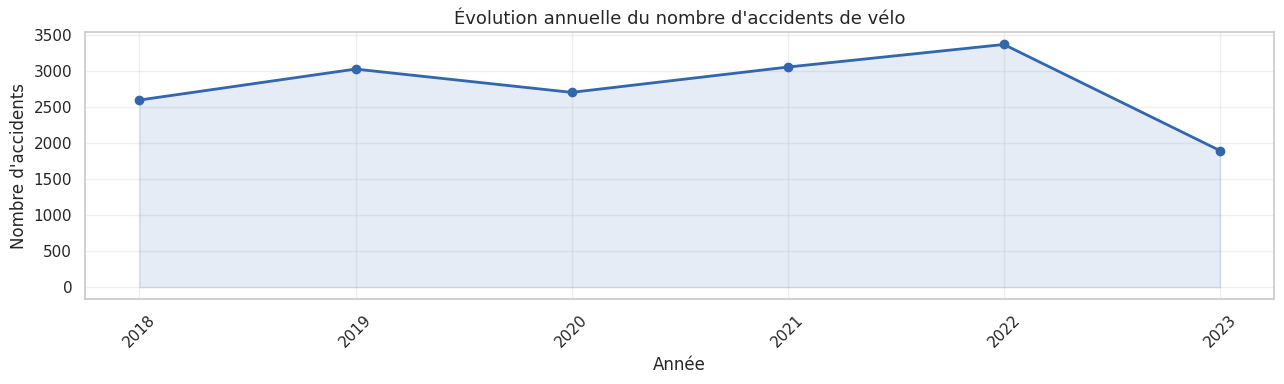

In [ ]:
# 5.1 Évolution annuelle
plt.figure(figsize=(13, 4))
acc_an = df.groupby('an').size()
plt.plot(acc_an.index, acc_an.values, marker='o', color='#3266ad', linewidth=2)
plt.fill_between(acc_an.index, acc_an.values, alpha=0.12, color='#3266ad')
plt.title("Évolution annuelle du nombre d'accidents de vélo", fontsize=13)
plt.xlabel('Année')
plt.ylabel("Nombre d'accidents")
plt.xticks(acc_an.index, rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Biais temporel majeur** : deux périodes très distinctes :
- **2005–2017** : stable entre 4 300 et 5 400 accidents/an
- **À partir de 2018** : chute brutale (~4 800 → ~2 600), non expliquée par une baisse réelle de la pratique

Cette rupture reflète vraisemblablement un **changement de périmètre ou de méthode de collecte**. 2023 est probablement incomplet si le dataset a été extrait en cours d'année.

→ Pour la modélisation : pour `an` se restreindre à une période homogène.

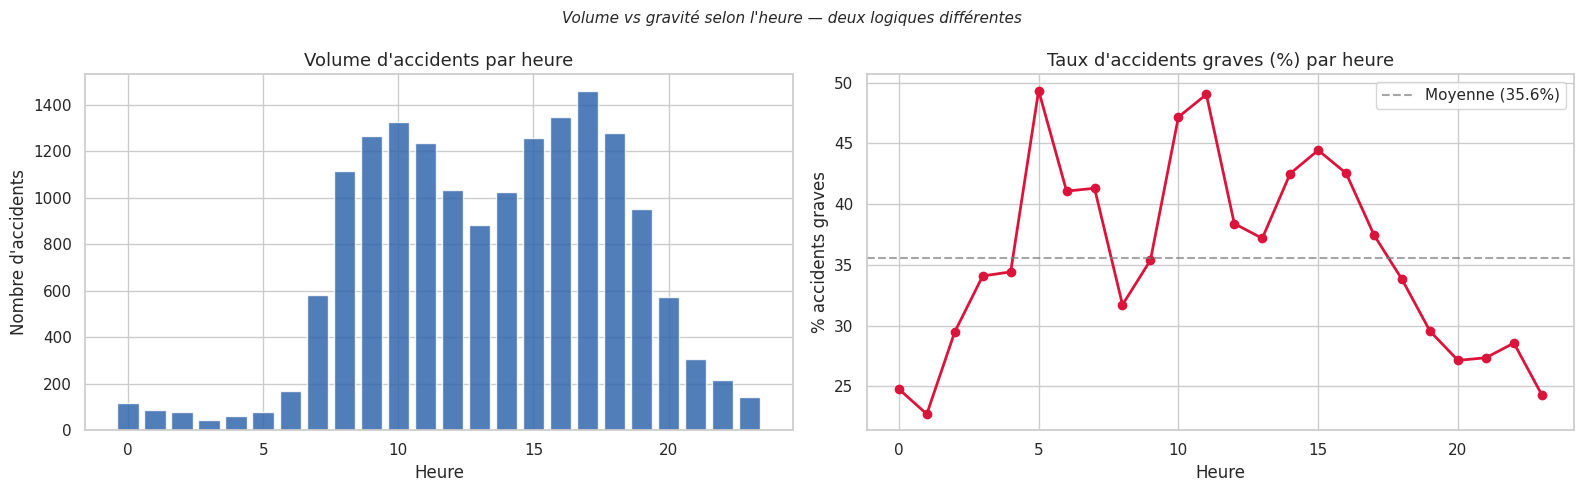

In [ ]:
# 5.2 Volume vs taux de gravité selon l'heure
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

acc_heure = df.groupby('heure').size()
axes[0].bar(acc_heure.index, acc_heure.values, color='#3266ad', alpha=0.85)
axes[0].set_title("Volume d'accidents par heure", fontsize=13)
axes[0].set_xlabel('Heure')
axes[0].set_ylabel("Nombre d'accidents")

taux_heure = df.groupby('heure')['grav_bin'].mean() * 100
axes[1].plot(taux_heure.index, taux_heure.values, marker='o', color='crimson', linewidth=2)
axes[1].axhline(y=taux_heure.mean(), color='gray', linestyle='--', alpha=0.7,
                label=f'Moyenne ({taux_heure.mean():.1f}%)')
axes[1].set_title("Taux d'accidents graves (%) par heure", fontsize=13)
axes[1].set_xlabel('Heure')
axes[1].set_ylabel('% accidents graves')
axes[1].legend()

plt.suptitle("Volume vs gravité selon l'heure — deux logiques différentes",
             fontsize=11, style='italic')
plt.tight_layout()
plt.show()

**Dissociation volume / gravité : résultat clé :**
- Le **pic de volume** est à 17h-18h (retour domicile-travail)
- Le **pic de gravité** est la **nuit (0h-6h)** : peu d'accidents, mais les plus meurtriers (vitesses élevées, visibilité nulle)
- Le matin 8h-9h cumule **volume ET gravité élevés** : doublement dangereux

-> Pour le feature engineering : créer `heure_nuit` (0h-6h) et `heure_pointe` (7h-9h / 16h-19h)

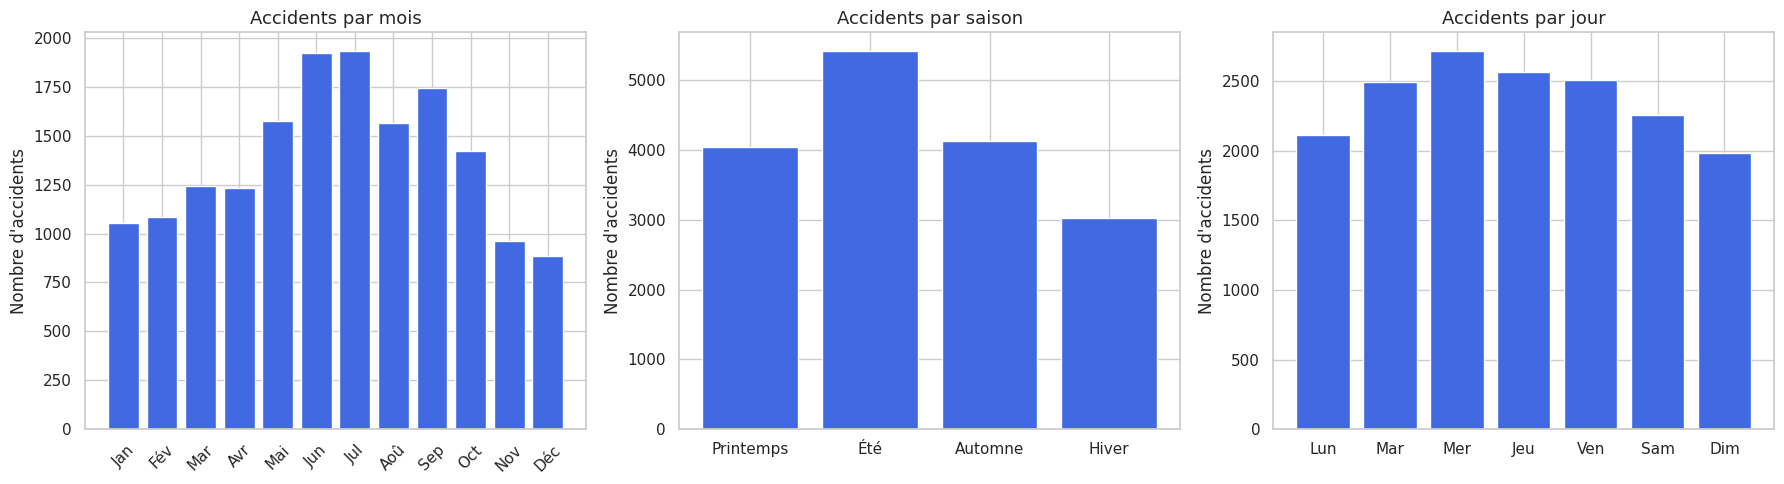

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mois_abbr = {1:'Jan', 2:'Fév', 3:'Mar', 4:'Avr', 5:'Mai', 6:'Jun',
             7:'Jul', 8:'Aoû', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Déc'}
acc_mois = df.groupby('mois_num').size()
axes[0].bar([mois_abbr[m] for m in acc_mois.index], acc_mois.values, color='royalblue')
axes[0].set_title('Accidents par mois', fontsize=13)
axes[0].set_ylabel("Nombre d'accidents")
axes[0].tick_params(axis='x', rotation=45)

ordre_saisons = ['Printemps', 'Été', 'Automne', 'Hiver']
acc_saison = df['saison'].value_counts().reindex(ordre_saisons)
axes[1].bar(ordre_saisons, acc_saison.values, color='royalblue')
axes[1].set_title('Accidents par saison', fontsize=13)
axes[1].set_ylabel("Nombre d'accidents")

jours_abbr = {0:'Lun', 1:'Mar', 2:'Mer', 3:'Jeu', 4:'Ven', 5:'Sam', 6:'Dim'}
acc_jour = df.groupby('jour_num').size()
axes[2].bar([jours_abbr[j] for j in acc_jour.index], acc_jour.values, color='royalblue')
axes[2].set_title('Accidents par jour', fontsize=13)
axes[2].set_ylabel("Nombre d'accidents")

plt.tight_layout()
plt.show()

Sans surprise l'été concentre le plus d'accidents (plus de 5 000), les gens roulent
plus quand il fait beau. Juin et juillet sont les mois les plus accidentogènes,
février le plus calme.

En semaine il y a nettement plus d'accidents qu'en week-end,
profil domicile-travail classique.

Par contre côté gravité c'est l'été qui est le
plus meurtrier (43%), probablement lié aux vitesses plus élevées et aux déplacements
de loisir hors agglomération.

L'hiver a le taux de gravité le plus faible (33%),
les cyclistes roulent plus prudemment par mauvais temps.

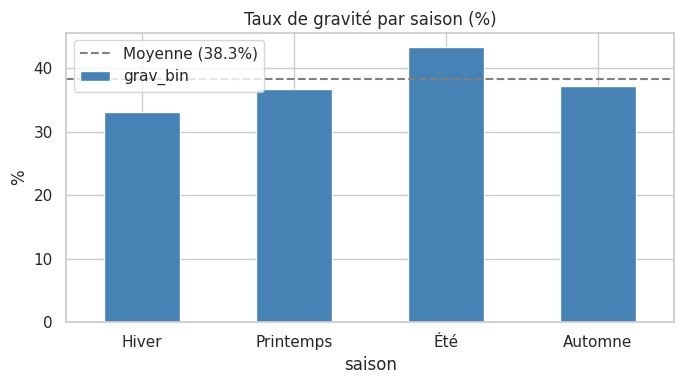

In [ ]:
# graph saison vs grav
taux_saison = df.groupby('saison')['grav_bin'].mean() * 100
taux_saison = taux_saison.reindex(['Hiver', 'Printemps', 'Été', 'Automne'])

taux_saison.plot(kind='bar', color='steelblue', figsize=(7, 4))
plt.axhline(df['grav_bin'].mean() * 100, color='gray', linestyle='--',
            label=f"Moyenne ({df['grav_bin'].mean()*100:.1f}%)")
plt.title('Taux de gravité par saison (%)')
plt.ylabel('%')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()


- **Saisonnalité très marquée** : pic en juin (environ 9 000 accidents), creux en février (environ 4 200). La période mai-octobre concentre la majorité des accidents, ca peut tout simplement s'expliquement par le fait que les conditions météo favorisent la pratique.
- **Semaine vs week-end** : nettement plus d'accidents en semaine, profil de déplacements domicile-travail dominant.

Cette analyse temporelle met en évidence deux logiques qu'il faut bien distinguer :

- le volume d'accidents suit la pratique du vélo (plus on roule, plus on tombe),
- la gravité suit les conditions de conduite (vitesse, visibilité, infrastructure).


Ces deux dimensions ne sont pas corrélées, ce qui justifie de créer des variables
spécifiques pour chacune plutôt que de garder l'heure ou la saison brutes.

## **6. Facteurs de risque environnementaux**

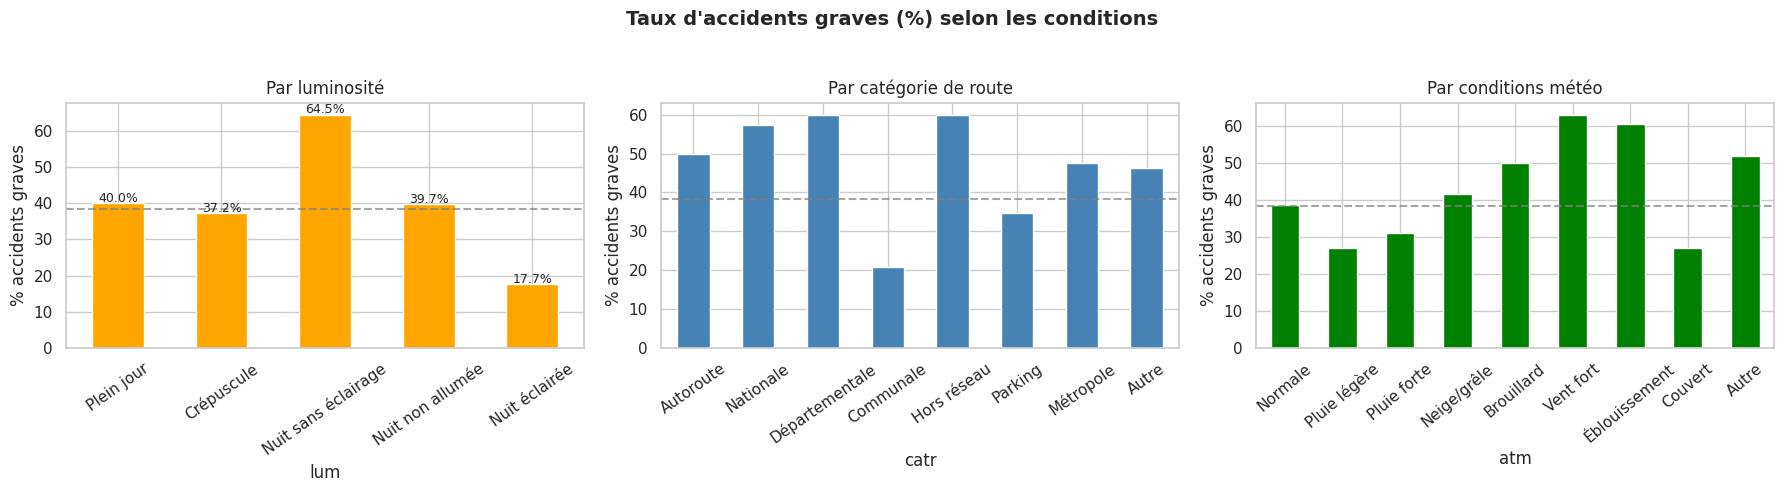

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Taux d'accidents graves (%) selon les conditions", fontsize=14, fontweight='bold')
moy_glob = df['grav_bin'].mean() * 100

lum_labels = {1:'Plein jour', 2:'Crépuscule', 3:'Nuit sans éclairage',
              4:'Nuit non allumée', 5:'Nuit éclairée'}
taux_lum = df.groupby('lum')['grav_bin'].mean() * 100
taux_lum.index = taux_lum.index.map(lum_labels)
taux_lum.plot(kind='bar', ax=axes[0], color='orange')
axes[0].axhline(moy_glob, color='gray', linestyle='--', alpha=0.7)
axes[0].set_title('Par luminosité')
axes[0].set_ylabel('% accidents graves')
axes[0].tick_params(axis='x', rotation=35)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.4),
                     ha='center', fontsize=9)

catr_labels = {1:'Autoroute', 2:'Nationale', 3:'Départementale',
               4:'Communale', 5:'Hors réseau', 6:'Parking', 7:'Métropole', 9:'Autre'}
taux_catr = df.groupby('catr')['grav_bin'].mean() * 100
taux_catr.index = taux_catr.index.map(lambda x: catr_labels.get(x, str(x)))
taux_catr.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].axhline(moy_glob, color='gray', linestyle='--', alpha=0.7)
axes[1].set_title('Par catégorie de route')
axes[1].set_ylabel('% accidents graves')
axes[1].tick_params(axis='x', rotation=35)

atm_labels = {1:'Normale', 2:'Pluie légère', 3:'Pluie forte',
              4:'Neige/grêle', 5:'Brouillard', 6:'Vent fort',
              7:'Éblouissement', 8:'Couvert', 9:'Autre'}
taux_atm = df.groupby('atm')['grav_bin'].mean() * 100
taux_atm.index = taux_atm.index.map(lambda x: atm_labels.get(x, str(x)))
taux_atm.plot(kind='bar', ax=axes[2], color='green')
axes[2].axhline(moy_glob, color='gray', linestyle='--', alpha=0.7)
axes[2].set_title('Par conditions météo')
axes[2].set_ylabel('% accidents graves')
axes[2].tick_params(axis='x', rotation=40)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

- **Luminosité** : nuit sans éclairage -> environ 63% de graves, soit presque le double du taux en plein jour (environ 37%). Variable la plus discriminante visuellement.
- **Catégorie de route** : départementales et nationales les plus mortelles (environ 50-60%) car les vitesses y sont plus élevées. Routes communales les plus sûres (environ 25%).
- **Météo** : vent fort et brouillard sont les conditions les plus mortelles (environ 60–63%). La pluie légère est paradoxalement peu grave (les cyclistes ralentissent spontanément).

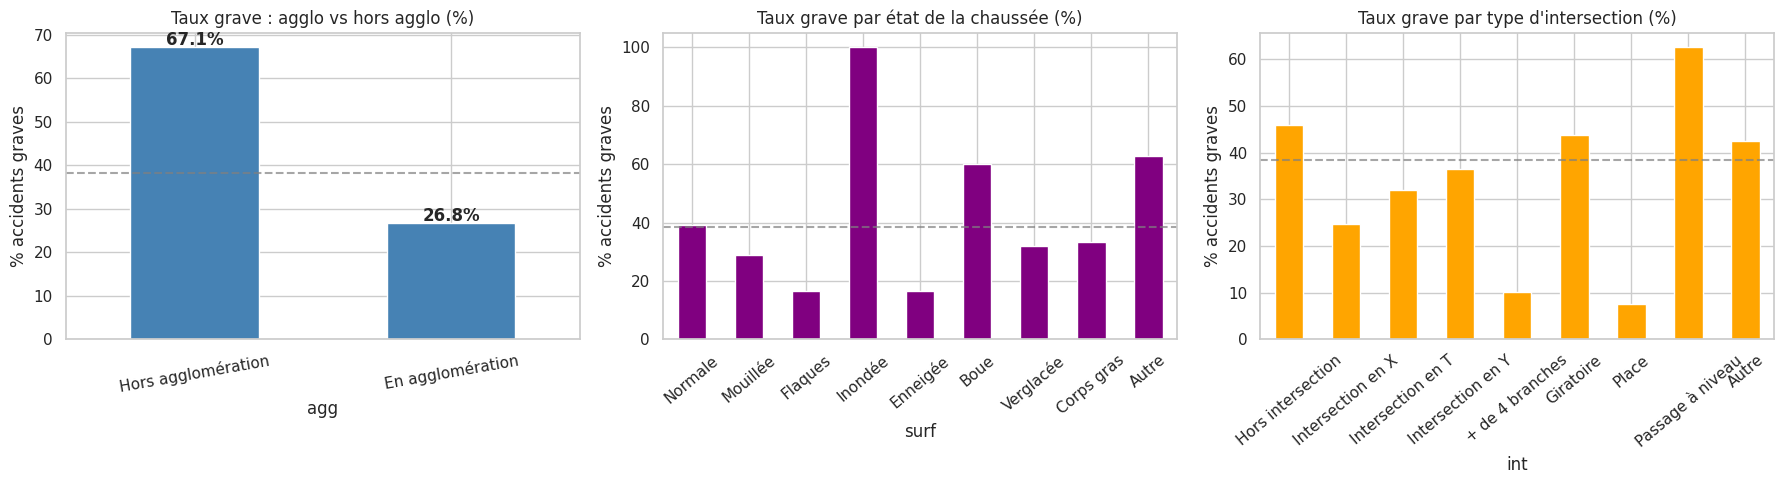

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

agg_labels = {1: 'Hors agglomération', 2: 'En agglomération'}
taux_agg = df.groupby('agg')['grav_bin'].mean() * 100
taux_agg.index = taux_agg.index.map(agg_labels)
taux_agg.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].axhline(moy_glob, color='gray', linestyle='--', alpha=0.7)
axes[0].set_title('Taux grave : agglo vs hors agglo (%)')
axes[0].set_ylabel('% accidents graves')
axes[0].tick_params(axis='x', rotation=10)
for i, v in enumerate(taux_agg.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)

surf_labels = {1:'Normale', 2:'Mouillée', 3:'Flaques', 4:'Inondée',
               5:'Enneigée', 6:'Boue', 7:'Verglacée', 8:'Corps gras', 9:'Autre'}
taux_surf = df.groupby('surf')['grav_bin'].mean() * 100
taux_surf.index = taux_surf.index.map(lambda x: surf_labels.get(x, str(x)))
taux_surf.plot(kind='bar', ax=axes[1], color='purple')
axes[1].axhline(moy_glob, color='gray', linestyle='--', alpha=0.7)
axes[1].set_title('Taux grave par état de la chaussée (%)')
axes[1].set_ylabel('% accidents graves')
axes[1].tick_params(axis='x', rotation=40)

int_labels = {1:'Hors intersection', 2:'Intersection en X', 3:'Intersection en T',
              4:'Intersection en Y', 5:'+ de 4 branches', 6:'Giratoire',
              7:'Place', 8:'Passage à niveau', 9:'Autre'}
taux_int = df.groupby('int')['grav_bin'].mean() * 100
taux_int.index = taux_int.index.map(lambda x: int_labels.get(x, str(x)))
taux_int.plot(kind='bar', ax=axes[2], color='orange')
axes[2].axhline(moy_glob, color='gray', linestyle='--', alpha=0.7)
axes[2].set_title("Taux grave par type d'intersection (%)")
axes[2].set_ylabel('% accidents graves')
axes[2].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.show()

- **Hors agglomération** : taux de gravité nettement supérieur -> vitesses plus élevées, secours plus longs à arriver, infrastructure moins adaptée aux cyclistes.
- **État de la chaussée** : verglas et neige génèrent les accidents les plus graves. La surface normale reste la plus représentée en volume.
- **Intersections** : les accidents hors intersection sont souvent les plus graves (chocs à vitesse élevée sur route ouverte).

### Géographie

/tmp/ipykernel_12441/576219363.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=taux_agg.index, y=taux_agg.values,
/tmp/ipykernel_12441/576219363.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=volume_agg.index, y=volume_agg.values,


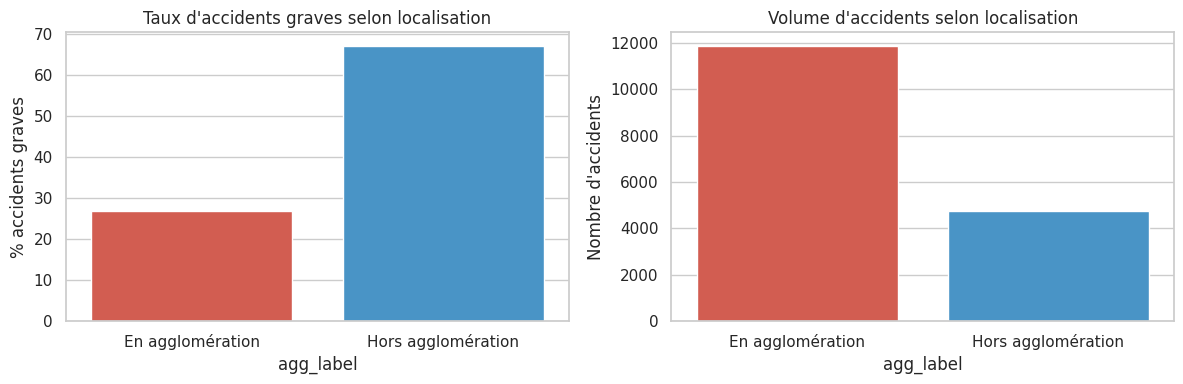

In [ ]:
#Agglomération vs hors agglo
df_agg = df[df['agg'].isin([1,2])].copy()
df_agg['agg_label'] = df_agg['agg'].map({1:'Hors agglomération', 2:'En agglomération'})
df_agg['grav_bin'] = df_agg['grav'].apply(lambda x: 1 if x in [2,3] else 0)

taux_agg = df_agg.groupby('agg_label')['grav_bin'].mean() * 100
volume_agg = df_agg.groupby('agg_label').size()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(x=taux_agg.index, y=taux_agg.values,
            palette=['#e74c3c','#3498db'], ax=axes[0])
axes[0].set_title("Taux d'accidents graves selon localisation")
axes[0].set_ylabel("% accidents graves")

sns.barplot(x=volume_agg.index, y=volume_agg.values,
            palette=['#e74c3c','#3498db'], ax=axes[1])
axes[1].set_title("Volume d'accidents selon localisation")
axes[1].set_ylabel("Nombre d'accidents")

plt.tight_layout()
plt.show()

La ville concentre 80% des accidents,c'est hors agglomération que les accidents sont les plus mortels.
- Vitesses plus élevées, routes moins sécurisées, secours plus longs.
- agg est la variable la plus discriminante du dataset

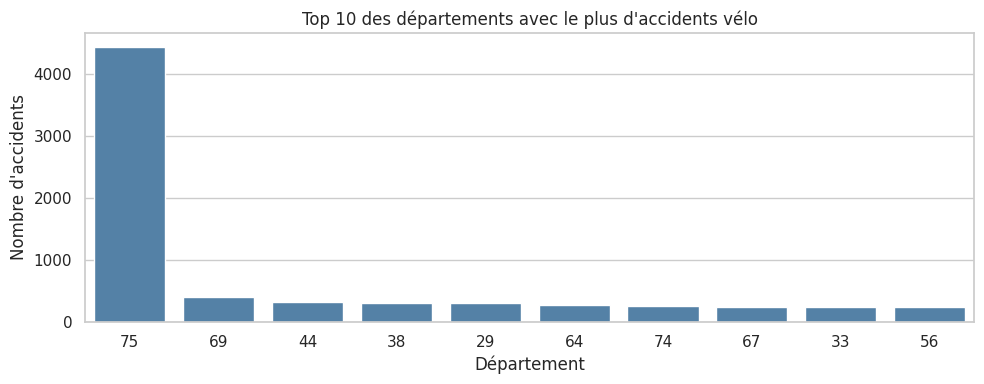

In [ ]:
#Top 10 départements les plus accidentogènes
top_dep = df.groupby('dep').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 4))
sns.barplot(x=top_dep.index.astype(str), y=top_dep.values, color='steelblue')
plt.title("Top 10 des départements avec le plus d'accidents vélo")
plt.xlabel("Département")
plt.ylabel("Nombre d'accidents")
plt.tight_layout()
plt.show()

ATTENTION Biais : Ce classement reflète le VOLUME, pas la dangerosité.

Paris a plus d'accidents car il y a beaucoup plus de cyclistes.
- Pour mesurer la dangerosité réelle il faudrait ramener
  le nombre d'accidents au nombre de cyclistes (taux d'exposition)
- donnée qu'on n'a pas dans ce dataset.
  C'est une limite à mentionner dans la discussion critique.

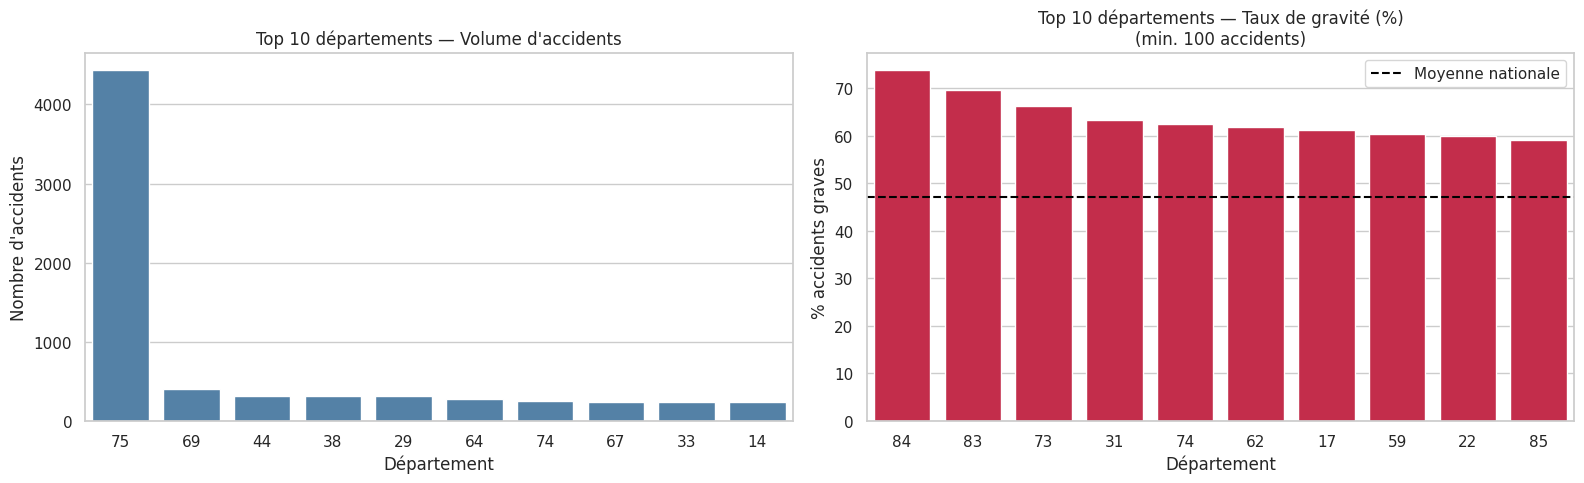

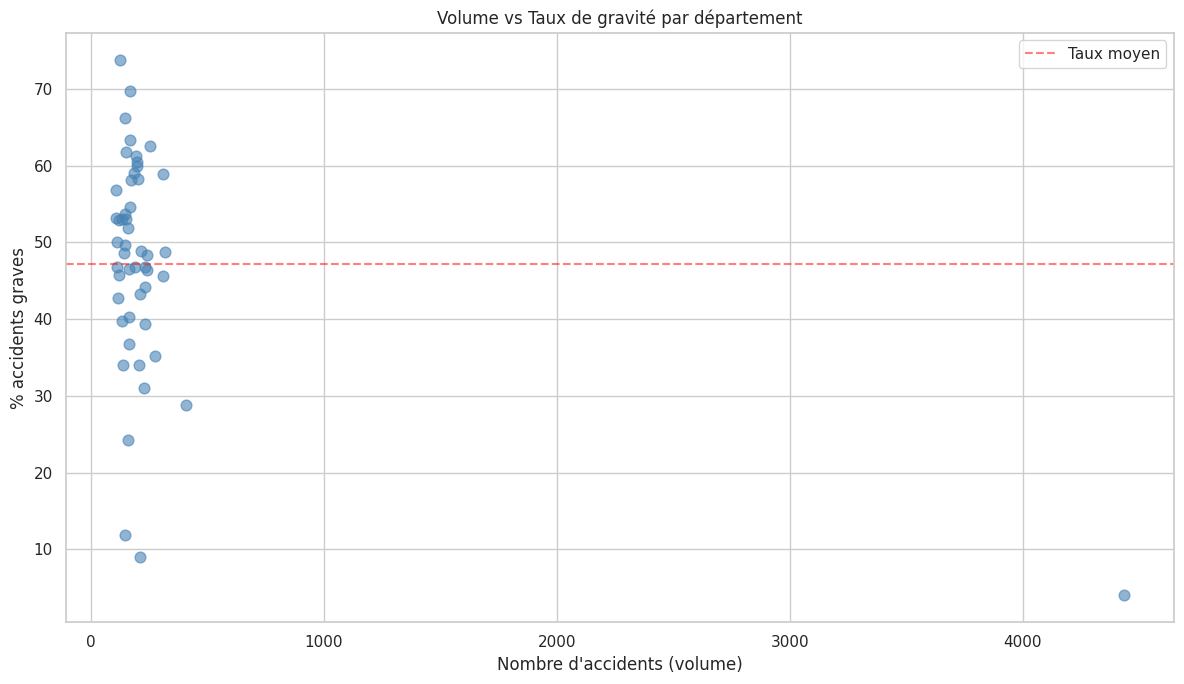

Départements les plus dangereux (taux de gravité)
dep  volume  taux_grave
 84     126       73.81
 83     165       69.70
 73     145       66.21
 31     169       63.31
 74     251       62.55
 62     149       61.74
 17     191       61.26
 59     197       60.41
 22     197       59.90
 85     183       59.02

 Départements les plus accidentogènes (volume)
dep  volume  taux_grave
 75    4434        3.99
 69     406       28.82
 44     316       48.73
 38     309       58.90
 29     307       45.60
 64     276       35.14
 74     251       62.55
 67     239       46.44
 33     238       48.32
 14     231       39.39


In [ ]:
# volume vs taux de gravité

df_dep = df[df['grav'].isin([1,2,3,4])].copy()
df_dep['grav_bin'] = df_dep['grav'].apply(lambda x: 1 if x in [2,3] else 0)

# Calcul volume et taux par département
stats_dep = df_dep.groupby('dep').agg(
    volume=('grav_bin', 'count'),
    taux_grave=('grav_bin', 'mean')
).reset_index()
stats_dep['taux_grave'] = stats_dep['taux_grave'] * 100

# -- 1. Top 10 volume vs Top 10 taux de gravité côte à côte
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 10 volume
top_volume = stats_dep.nlargest(10, 'volume')
sns.barplot(data=top_volume, x='dep', y='volume',
            color='steelblue', ax=axes[0])
axes[0].set_title("Top 10 départements — Volume d'accidents")
axes[0].set_xlabel("Département")
axes[0].set_ylabel("Nombre d'accidents")

# Top 10 taux de gravité (minimum 100 accidents pour éviter les petits dep)
stats_dep_filtre = stats_dep[stats_dep['volume'] >= 100]
top_taux = stats_dep_filtre.nlargest(10, 'taux_grave')
sns.barplot(data=top_taux, x='dep', y='taux_grave',
            color='crimson', ax=axes[1])
axes[1].set_title("Top 10 départements — Taux de gravité (%)\n(min. 100 accidents)")
axes[1].set_xlabel("Département")
axes[1].set_ylabel("% accidents graves")
axes[1].axhline(y=stats_dep_filtre['taux_grave'].mean(),
                color='black', linestyle='--', label='Moyenne nationale')
axes[1].legend()

plt.tight_layout()
plt.show()

# 2. Scatter plot : volume vs taux de gravité (vue d'ensemble)
plt.figure(figsize=(12, 7))
plt.scatter(stats_dep_filtre['volume'], stats_dep_filtre['taux_grave'],
            alpha=0.6, color='steelblue', s=60)

# Annoter les départements notables
deps_notables = [75, 69, 33, 13, 59, 67]
for _, row in stats_dep_filtre[stats_dep_filtre['dep'].isin(deps_notables)].iterrows():
    plt.annotate(str(int(row['dep'])),
                 xy=(row['volume'], row['taux_grave']),
                 xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.axhline(y=stats_dep_filtre['taux_grave'].mean(),
            color='red', linestyle='--', alpha=0.5, label='Taux moyen')
plt.title("Volume vs Taux de gravité par département")
plt.xlabel("Nombre d'accidents (volume)")
plt.ylabel("% accidents graves")
plt.legend()
plt.tight_layout()
plt.show()

# Résumé chiffré
print("Départements les plus dangereux (taux de gravité)")
print(top_taux[['dep','volume','taux_grave']].to_string(index=False))
print("\n Départements les plus accidentogènes (volume)")
print(top_volume[['dep','volume','taux_grave']].to_string(index=False))

Paris (75) écrase le classement avec environ 4 400 accidents, loin devant Lyon (69)
et Nantes (44).

Mais attention ce classement ne veut pas dire que Paris est dangereux,
il y a juste beaucoup plus de cyclistes. Le scatter plot le confirme : Paris se retrouve
tout en bas à droite avec un taux de gravité de seulement 4%, les départements les plus
meurtriers sont des départements ruraux (84, 83, 73) avec des taux supérieurs à 65%
mais des volumes faibles. Volume et dangerosité sont deux choses complètement différentes.

Les conditions les plus meurtrières se cumulent souvent : nuit sans éclairage,
hors agglomération, sur une départementale. C'est exactement ce qu'on va capturer
avec la variable `hors_agglo_nuit` en feature engineering. La variable `agg` est
clairement la plus discriminante de toute l'analyse avec 40 points d'écart entre
ville et hors agglomération.

## **7. Profil des victimes**

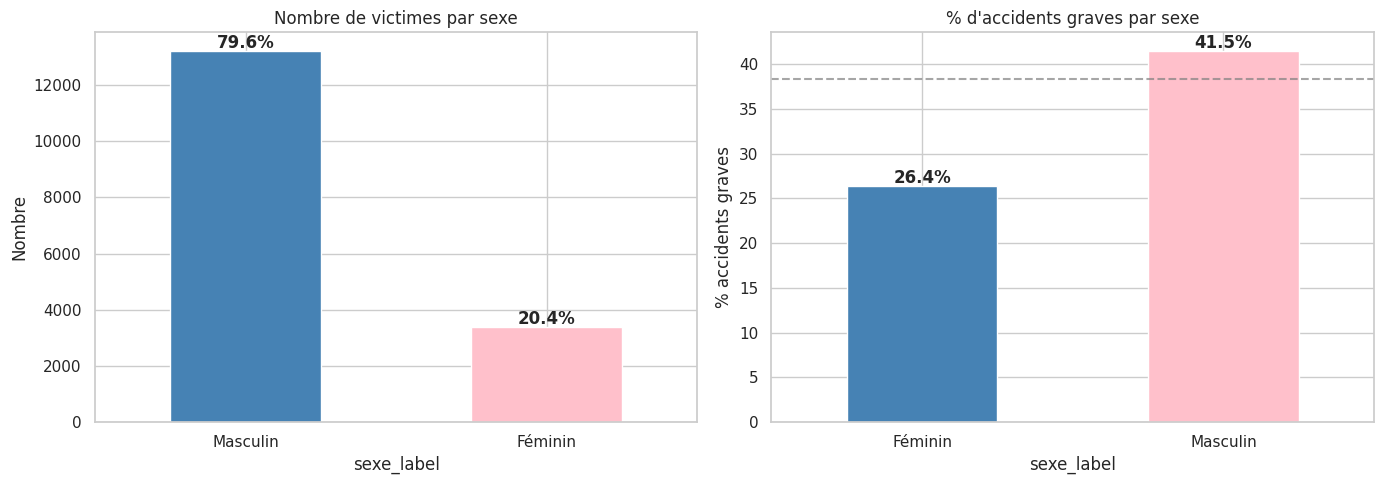

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_s = df[df['sexe'].isin([1, 2])].copy()
df_s['sexe_label'] = df_s['sexe'].map({1: 'Masculin', 2: 'Féminin'})

counts_sexe = df_s['sexe_label'].value_counts()
counts_sexe.plot(kind='bar', ax=axes[0], color=['steelblue', 'pink'])
axes[0].set_title('Nombre de victimes par sexe')
axes[0].set_ylabel('Nombre')
axes[0].tick_params(axis='x', rotation=0)
total_s = counts_sexe.sum()
for i, v in enumerate(counts_sexe.values):
    axes[0].text(i, v + 100, f'{v/total_s*100:.1f}%', ha='center', fontweight='bold')

taux_sexe = df_s.groupby('sexe_label')['grav_bin'].mean() * 100
taux_sexe.plot(kind='bar', ax=axes[1], color=['steelblue', 'pink'], legend=False)
axes[1].axhline(df['grav_bin'].mean()*100, color='gray', linestyle='--', alpha=0.7)
axes[1].set_title("% d'accidents graves par sexe")
axes[1].set_ylabel('% accidents graves')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(taux_sexe.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Les hommes représentent 79.6% des victimes mais c'est surtout une question d'exposition,
ils roulent plus. Ce qui est plus intéressant c'est le taux de gravité : les hommes
sont à 41.5% de graves contre 26.4% pour les femmes. Comportements à risque différents,
vitesses plus élevées, itinéraires plus exposés.

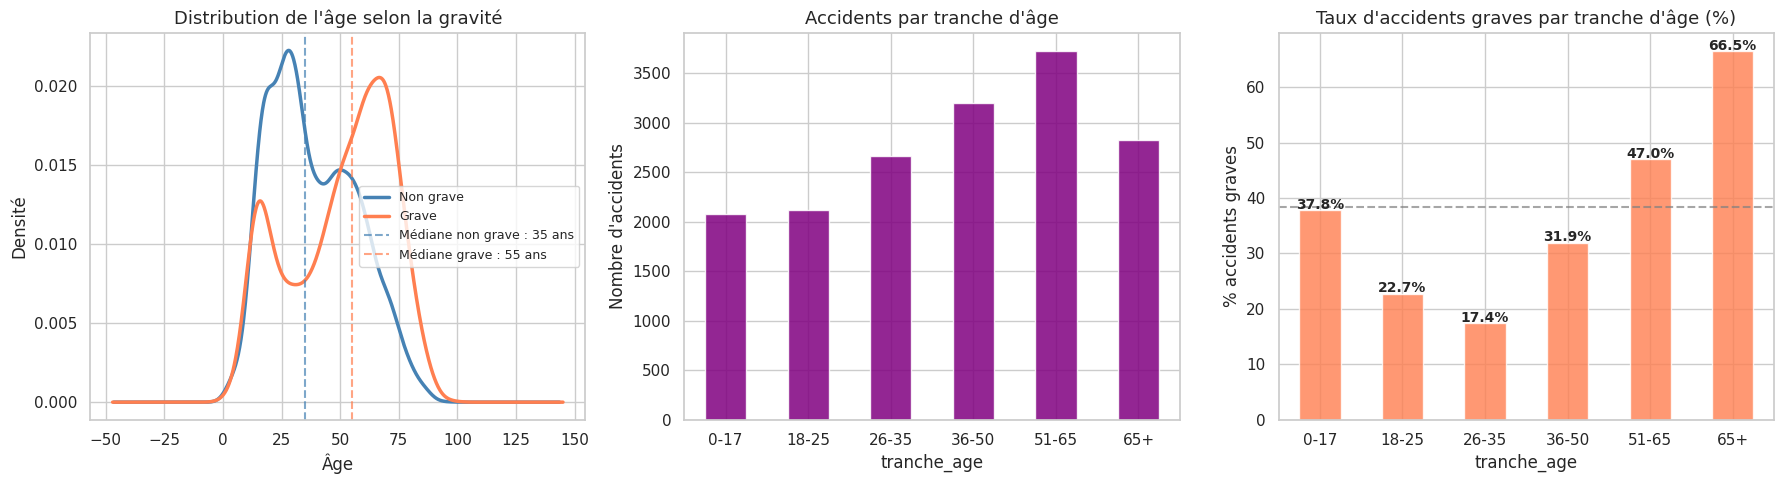

In [ ]:
bins       = [0, 17, 25, 35, 50, 65, 100]
labels_age = ['0-17', '18-25', '26-35', '36-50', '51-65', '65+']
df['tranche_age'] = pd.cut(df['age'], bins=bins, labels=labels_age)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_age = df[df['age'].between(0, 100)]
med_0  = df_age[df_age['grav_bin'] == 0]['age'].median()
med_1  = df_age[df_age['grav_bin'] == 1]['age'].median()

df_age[df_age['grav_bin'] == 0]['age'].plot(kind='kde', ax=axes[0], color='steelblue',
                                             linewidth=2.5, label='Non grave')
df_age[df_age['grav_bin'] == 1]['age'].plot(kind='kde', ax=axes[0], color='coral',
                                             linewidth=2.5, label='Grave')
axes[0].axvline(med_0, color='steelblue', linestyle='--', alpha=0.7,
                label=f'Médiane non grave : {med_0:.0f} ans')
axes[0].axvline(med_1, color='coral', linestyle='--', alpha=0.7,
                label=f'Médiane grave : {med_1:.0f} ans')
axes[0].set_title("Distribution de l'âge selon la gravité", fontsize=13)
axes[0].set_xlabel('Âge')
axes[0].set_ylabel('Densité')
axes[0].legend(fontsize=9)

df['tranche_age'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='purple', alpha=0.85)
axes[1].set_title("Accidents par tranche d'âge", fontsize=13)
axes[1].set_ylabel("Nombre d'accidents")
axes[1].tick_params(axis='x', rotation=0)

taux_age = df.groupby('tranche_age', observed=True)['grav_bin'].mean() * 100
taux_age.plot(kind='bar', ax=axes[2], color='coral', alpha=0.8, legend=False)
axes[2].axhline(df['grav_bin'].mean()*100, color='gray', linestyle='--', alpha=0.7)
axes[2].set_title("Taux d'accidents graves par tranche d'âge (%)", fontsize=13)
axes[2].set_ylabel('% accidents graves')
axes[2].tick_params(axis='x', rotation=0)
for i, v in enumerate(taux_age.values):
    axes[2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

L'effet de l'âge est très clair. Médiane à 55 ans pour les graves contre 35 ans pour
les non graves. Les 65+ ont un taux de gravité de 66.5%, plus du double de la moyenne.
Les 18-25 ans sont à 22.7% malgré une forte exposition, meilleure réactivité physique.
L'effet n'est pas linéaire : il chute entre 18 et 35 ans puis remonte progressivement,
ce qui justifie de créer des tranches plutôt que de garder l'âge brut.

Deux profils ressortent clairement comme les plus à risque : le cycliste senior (65+)
et le cycliste masculin hors agglomération. Ces résultats vont directement alimenter
le feature engineering avec les variables `senior`, `jeune_adulte` et `enfant`.


À noter que volume et gravité ne racontent pas la même histoire ici non plus :
les hommes ont beaucoup plus d'accidents mais ce sont les femmes et les jeunes
qui s'en sortent le mieux quand ils en ont un.

## **8. Corrélations & tests statistiques**

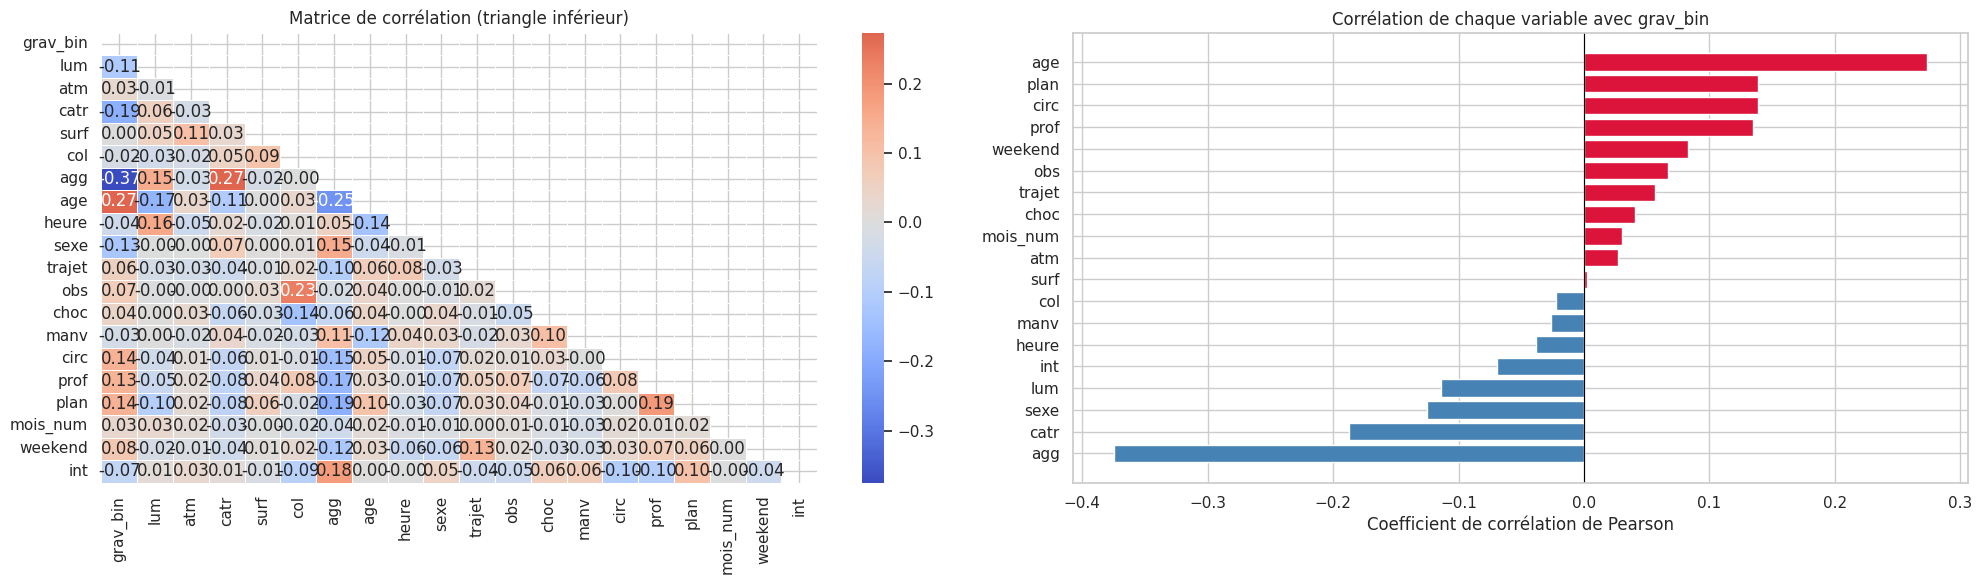

Top variables corrélées avec grav_bin :
agg    0.38
age    0.27
catr   0.19
plan   0.14
circ   0.14
prof   0.14
sexe   0.12
lum    0.11


In [ ]:
# Heatmap de corrélation — variables numériques vs grav_bin
cols_corr = ['grav_bin', 'lum', 'atm', 'catr', 'surf', 'col', 'agg',
             'age', 'heure', 'sexe', 'trajet', 'obs', 'choc', 'manv',
             'circ', 'prof', 'plan', 'mois_num', 'weekend', 'int']
cols_corr = [c for c in cols_corr if c in df.columns]

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

corr_matrix = df[cols_corr].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=axes[0])
axes[0].set_title('Matrice de corrélation (triangle inférieur)', fontsize=12)

corr_cible = corr_matrix['grav_bin'].drop('grav_bin').sort_values()
colors = ['crimson' if v > 0 else 'steelblue' for v in corr_cible]
axes[1].barh(corr_cible.index, corr_cible.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Corrélation de chaque variable avec grav_bin', fontsize=12)
axes[1].set_xlabel('Coefficient de corrélation de Pearson')

plt.tight_layout()
plt.show()

print('Top variables corrélées avec grav_bin :')
print(corr_cible.abs().sort_values(ascending=False).head(8).round(3).to_string())

Les corrélations linéaires sont globalement **faibles** (< 0.35), ce qui est attendu pour des variables catégorielles codées en entiers. `agg` (-0.33) est la plus corrélée : hors agglomération -> plus grave. Ces faibles corrélations **justifient l'utilisation de modèles non-linéaires** par la suite.

In [ ]:
# Test du Chi2, variables catégorielles vs grav_bin
# H0 : les variables sont indépendantes.
# p < 0.05 -> on rejette H0 -> lien statistiquement significatif.

cols_chi2 = ['lum', 'atm', 'surf', 'catr', 'int', 'agg', 'sexe',
             'trajet', 'col', 'choc', 'manv', 'weekend', 'saison']
cols_chi2 = [c for c in cols_chi2 if c in df.columns]

print('TEST DU CHI2, Variables catégorielles vs grav_bin')
print(f"{'Variable':<15} {'Chi2':>12} {'p-value':>14} {'Significatif':>14}")
print('-' * 58)

for col in cols_chi2:
    df_temp = df[[col, 'grav_bin']].dropna()
    table = pd.crosstab(df_temp[col], df_temp['grav_bin'])
    chi2, p, dof, _ = chi2_contingency(table)
    sig = 'OUI' if p < 0.05 else 'NON'
    print(f"{col:<15} {chi2:>12.1f} {p:>14.4f} {sig:>14}")

TEST DU CHI2, Variables catégorielles vs grav_bin
Variable                Chi2        p-value   Significatif
----------------------------------------------------------
lum                    468.9         0.0000            OUI
atm                    262.3         0.0000            OUI
surf                   111.2         0.0000            OUI
catr                  2569.5         0.0000            OUI
int                    693.9         0.0000            OUI
agg                   2335.2         0.0000            OUI
sexe                   259.1         0.0000            OUI
trajet                1671.6         0.0000            OUI
col                    590.3         0.0000            OUI
choc                   321.7         0.0000            OUI
manv                   414.4         0.0000            OUI
weekend                113.8         0.0000            OUI
saison                 100.1         0.0000            OUI


**Résultats :**
- **Chi2** : toutes les variables catégorielles testées montrent un lien statistiquement significatif avec la gravité (p < 0.05), confirmant les patterns observés en EDA.
- Ces résultats valident le choix de ces variables comme features pour la modélisation.


Les variables les plus liées à la gravité sont :
- catr (catégorie de route) : Chi2 = 8985
- agg (agglomération) : Chi2 = 8761  
- trajet (motif) : Chi2 = 4073

ATTENTION Nuance : un Chi2 élevé ne signifie pas forcément
une forte corrélation: il est aussi influencé par
la taille de l'échantillon (80 000 lignes).
Avec autant de données, même des liens très faibles
deviennent statistiquement significatifs.
- C'est pourquoi la corrélation ET le Chi2
  doivent être lus ensemble.

In [ ]:
# Test de Mann-Whitney — variable continue (âge) vs grav_bin
# H0 : la distribution de l'âge est identique entre graves et non-graves
# On utilise Mann-Whitney (non-paramétrique) car l'âge n'est pas normalement distribué

age_non_grave = df[df['grav_bin'] == 0]['age'].dropna()
age_grave     = df[df['grav_bin'] == 1]['age'].dropna()

stat, p = mannwhitneyu(age_grave, age_non_grave, alternative='greater')

print("TEST DE MANN-WHITNEY — Âge vs Gravité")
print(f"  Médiane âge non graves : {age_non_grave.median():.1f} ans")
print(f"  Médiane âge graves     : {age_grave.median():.1f} ans")
print(f"  Statistique U          : {stat:.0f}")
print(f"  p-value                : {p:.2e}")
print(f"  Significatif (p<0.05)  : {'OUI' if p < 0.05 else 'NON'}")
print()
print("Interprétation : les cyclistes impliqués dans des accidents graves")
print("ont un âge significativement plus élevé que ceux des accidents non graves.")

TEST DE MANN-WHITNEY — Âge vs Gravité
  Médiane âge non graves : 35.0 ans
  Médiane âge graves     : 55.0 ans
  Statistique U          : 42886281
  p-value                : 1.36e-258
  Significatif (p<0.05)  : OUI

Interprétation : les cyclistes impliqués dans des accidents graves
ont un âge significativement plus élevé que ceux des accidents non graves.


La p-value permet de rejeter H0 sans ambiguïté : les graves sont
significativement plus âgés que les non-graves. L'écart de médiane est de 20 ans
(55 vs 35 ans), ce qui confirme et quantifie statistiquement le pattern observé
en section 7, et valide la création de la variable `senior` dans les fe




Les trois analyses se complètent bien. Les corrélations linéaires sont faibles (max 0.38
pour `agg`), ce qui veut dire qu'aucune variable seule n'explique la gravité. Le Chi2
confirme que toutes ont un lien statistiquement significatif avec elle. Le test de
Mann-Whitney ajoute une dimension supplémentaire : l'âge, variable continue, est lui
aussi un facteur discriminant majeur avec 20 ans d'écart de médiane entre graves et
non-graves (p=1.36e-258).

Ce n'est pas contradictoire : les relations sont réelles mais non-linéaires, d'où le
choix de modèles comme Random Forest et XGBoost capables de les capter. `agg` et `catr`
ressortent comme les variables les plus liées à la gravité dans les deux premières
analyses, et `age` confirme sa place parmi les facteurs de risque les plus robustes —
ce qui valide directement les choix de feature engineering de la section 9.



---



### Bilan de l'EDA

L'analyse exploratoire a permis de dégager plusieurs patterns clairs qui vont structurer
la suite du projet.

Le facteur de risque le plus puissant est la localisation : hors agglomération on monte
à 67% de graves contre 27% en ville, un écart de 40 points que aucune autre variable
n'atteint. Viennent ensuite la luminosité (64.5% de graves la nuit sans éclairage),
la catégorie de route (57-60% sur nationales et départementales) et l'âge (66.5%
de graves chez les 65+).

Ce qui est intéressant c'est que volume et gravité racontent systématiquement deux
histoires différentes : Paris concentre le plus d'accidents mais a un taux de gravité
de 4%, l'été a le plus d'accidents mais l'hiver a le taux de gravité le plus bas,
17h-18h c'est le pic d'accidents mais le pic de mortalité c'est la nuit. Cette
dissociation est un résultat clé qui justifie de ne pas se contenter du volume pour
évaluer le risque.

Les corrélations linéaires restent faibles (max 0.38) ce qui confirme que les relations
entre variables et gravité sont non-linéaires et qu'on aura besoin de modèles capables
de les capter. Tous les tests Chi2 sont significatifs, les variables sélectionnées
ont bien un lien réel avec la gravité.

Ces observations vont directement alimenter le feature engineering de la section 9 (variables construites à partir de patterns identifiés ici).

##**9. Feature engineering**

### Bilan de l'EDA — ce qu'on crée et pourquoi

L'EDA a mis en évidence plusieurs signaux qu'on ne peut pas exploiter directement tels quels. On crée donc des variables adaptées à ces observations.

**`heure_nuit` et `heure_pointe`** — l'heure brute cache une dissociation importante : le pic de volume est en soirée mais le pic de gravité est la nuit (22h-6h), et le matin (7h-9h) cumule volume ET gravité élevés. Garder `heure` seule ne suffit pas à capturer ça, d'où ces deux flags binaires.

**`is_hiver`, `is_ete`, `is_printemps`** — la saison montre une saisonnalité marquée sur le volume d'accidents. Plutôt que de garder `saison` en texte ou `mois_num` brut, on encode en dummies (Automne = référence).

**`periode_journee`** — découper la journée en 6 tranches (matin, matinée, midi, après-midi, soirée, nuit) donne au modèle un signal plus lisible qu'une heure brute à 24 valeurs.

**`weekend`** — nettement plus d'accidents en semaine (profil domicile-travail). Variable binaire simple et efficace.

**`nuit_sans_eclairage`** — depuis `lum`. C'est la condition la plus meurtrière du dataset (~63% de graves). Plus discriminante que `nuit` seule : l'éclairage public protège vraiment, la nuit éclairée ne représente que ~25% de graves.

**`mauvaises_conditions`** — depuis `atm` + `surf`. Résume en un seul flag les conditions météo ou de chaussée dégradées (pluie forte, brouillard, verglas, inondation...). 11.7% des accidents, mais taux de gravité au-dessus de la moyenne.

**`tiers_present`** — `manoeuvehicules`, `typevehicules` et `numVehicules` avaient des NaN informatifs (~55% chez les non-graves contre ~15% chez les graves). L'absence d'info signale souvent qu'il n'y avait pas de véhicule adverse. On condense en un flag binaire plutôt que d'imputer.

**`senior`, `jeune_adulte`, `enfant`** — l'âge est un signal fort (médiane ~50 ans pour les graves vs ~35 ans) mais son effet n'est pas linéaire. On découpe en tranches binaires pour que le modèle capte l'effet spécifique des seniors, physiologiquement plus fragiles.

**`hors_agglo_nuit`** — `agg` et `heure_nuit` sont chacun des facteurs de risque puissants. Leur combinaison représente le scénario le plus meurtrier observé en EDA, d'où cette variable d'interaction.

#### A. Variables temporelles

In [ ]:
# heure_nuit : 22h-6h → pic de gravité le plus élevé du dataset
df['heure_nuit']   = ((df['heure'] >= 22) | (df['heure'] <= 6)).astype(int)

# heure_pointe : 7h-9h ou 16h-19h → cumule volume ET gravité élevés
df['heure_pointe'] = (df['heure'].isin(range(7, 10)) | df['heure'].isin(range(16, 20))).astype(int)

# periode_journee : découpage en 6 tranches (plus lisible qu'une heure brute)
def periode_journee(h):
    if 6 <= h < 9:   return 'matin'
    elif 9 <= h < 12:  return 'matinee'
    elif 12 <= h < 14: return 'midi'
    elif 14 <= h < 18: return 'apres_midi'
    elif 18 <= h < 22: return 'soiree'
    else:              return 'nuit'

df['periode_journee'] = df['heure'].apply(periode_journee)

# Saison → dummies (Automne = référence, évite la multicolinéarité)
df['is_hiver']     = (df['saison'] == 'Hiver').astype(int)
df['is_ete']       = (df['saison'] == 'Été').astype(int)
df['is_printemps'] = (df['saison'] == 'Printemps').astype(int)

# Weekend
df['weekend'] = (df['jour_num'] >= 5).astype(int)

#### B. Conditions à risque

In [ ]:
# nuit_sans_eclairage : lum == 3 → condition la plus meurtrière (~63% de graves)
df['nuit_sans_eclairage'] = (df['lum'] == 3).astype(int)

# mauvaises_conditions : météo dégradée OU chaussée dégradée
df['mauvaises_conditions'] = (
    df['atm'].isin([2, 3, 4, 5, 6]) | df['surf'].isin([2, 3, 4, 5, 6, 7])
).astype(int)

#### C. Présence d'un tiers

In [ ]:
cols_tiers = [c for c in ['manoeuvehicules', 'typevehicules', 'numVehicules'] if c in df.columns]

if cols_tiers:
    df['tiers_present'] = df[cols_tiers].notnull().any(axis=1).astype(int)
else:
    df['tiers_present'] = df['col'].notnull().astype(int)

#### D. Profil de la victime & interaction

In [ ]:
df['senior']       = (df['age'] >= 65).astype(int)
df['jeune_adulte'] = (df['age'].between(18, 25)).astype(int)
df['enfant']       = (df['age'] < 18).astype(int)

# Interaction : hors agglo + nuit → combinaison la plus létale (EDA sections 5 & 6)
df['hors_agglo_nuit'] = ((df['agg'] == 1) & (df['heure_nuit'] == 1)).astype(int)

#### E. Encodage & imputation

In [ ]:
from sklearn.impute import SimpleImputer
import re

# 1. Nettoyage avant encodage
cols_ohe = [c for c in ['lum', 'atm', 'surf', 'col', 'int', 'choc', 'manv', 'trajet'] if c in df.columns]
for col in cols_ohe:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. One-Hot Encoding
df_ohe = pd.get_dummies(df[cols_ohe].astype('Int64').astype(str), prefix=cols_ohe, drop_first=True)

if 'periode_journee' in df.columns:
    df = pd.get_dummies(df, columns=['periode_journee'], drop_first=True, dtype=int)
cols_periode = [c for c in df.columns if c.startswith('periode_journee_')]

# 3. Construction de df_model
cols_keep = [c for c in [
    'agg', 'catr', 'circ', 'prof', 'plan',
    'sexe', 'trajet',
    'age', 'nbv', 'larrout',
    'heure', 'mois_num', 'weekend', 'jour_num',
    'heure_nuit', 'heure_pointe',
    'is_hiver', 'is_ete', 'is_printemps',
    'nuit_sans_eclairage', 'mauvaises_conditions',
    'tiers_present',
    'senior', 'jeune_adulte', 'enfant',
    'hors_agglo_nuit',
    'grav_bin'
] if c in df.columns]

df_model = pd.concat([df[cols_keep + cols_periode].copy(), df_ohe], axis=1)

# 4. Gestion des NaN
# Colonnes tiers : NaN = pas de tiers = 0
for col in ['manoeuvehicules', 'typevehicules', 'numVehicules']:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(0)

# Tout le reste (colonnes OHE) : NaN = modalité inconnue = 0
df_model = df_model.fillna(0)

# 5. Séparation X / y
X = df_model.drop(columns=['grav_bin'])
X.columns = [re.sub(r'[\[\]<]', '_', str(col)) for col in X.columns]
y = df_model['grav_bin']

# age, nbv, larrout : médiane (écrase les 0 mis à l'étape précédente)
cols_impute_mediane = [c for c in ['age', 'nbv', 'larrout'] if c in X.columns]
for col in cols_impute_mediane:
    X[col] = pd.to_numeric(X[col], errors='coerce')
imp = SimpleImputer(strategy='median')
X[cols_impute_mediane] = imp.fit_transform(X[cols_impute_mediane])

print(f"Shape finale : {X.shape[0]:,} lignes × {X.shape[1]} features — NaN résiduels : {X.isnull().sum().sum()}")
print(f"Taux de graves : {y.mean()*100:.1f}%")

Shape finale : 16,625 lignes × 113 features — NaN résiduels : 0
Taux de graves : 38.3%


### Conclusion du Feature Engineering

À ce stade le dataframe est prêt pour la modélisation. On part de 16 625 lignes, 131 features, zéro NaN et un taux de graves de 38.3%.

Par rapport aux données brutes, on a enrichi le dataset avec 11 variables construites qui traduisent directement les patterns identifiés en EDA : les conditions les plus meurtrières (`nuit_sans_eclairage`, `mauvaises_conditions`, `hors_agglo_nuit`), les profils de victimes à risque (`senior`, `jeune_adulte`, `enfant`), les créneaux horaires dangereux (`heure_nuit`, `heure_pointe`) et la présence d'un tiers (`tiers_present`).

Les corrélations linéaires étant globalement faibles (< 0.35), on s'oriente vers des modèles capables de capter des effets non-linéaires et des interactions entre variables. On va tester quatre approches :

- **Régression Logistique** — modèle de référence, simple et interprétable, servira de baseline de comparaison
- **Random Forest** — modèle non-linéaire, robuste aux interactions entre features, donne en bonus l'importance des variables
- **XGBoost** — version boostée, apprend de ses erreurs à chaque itération, généralement le plus performant sur des données tabulaires
- **SVM** — approche mathématique différente, cherche la meilleure frontière de séparation entre graves et non-graves

Pour comparer les modèles on s'appuiera sur l'accuracy, la précision, le recall et le F1-score — avec une attention particulière sur le **recall**, car rater un accident grave est bien plus problématique que l'inverse.

##**10. Machine Learning**

La démarche est identique pour les quatre modèles :
**Baseline -> Tuning -> Évaluation finale**.

**Stratégie commune retenue** (justifiée en 10.2) :
- Pas de SMOTE : le déséquilibre 38/62% est trop faible pour en bénéficier
- `class_weight='balanced'` pour tous les modèles qui le supportent
- **Un seul split train/test**, fait une fois et réutilisé partout
- **Un seul scaler**, fitté sur `X_train` uniquement, appliqué à `X_test`
- RF et XGBoost travaillent sur les données brutes (insensibles à l'échelle)
- LR et SVM travaillent sur les données normalisées (`X_train_sc` / `X_test_sc`)

###**10.1 Split train / test**

In [ ]:
# Fait UNE SEULE FOIS : tous les modèles utilisent ce même split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]:,} lignes — taux graves : {y_train.mean()*100:.1f}%")
print(f"Test  : {X_test.shape[0]:,}  lignes — taux graves : {y_test.mean()*100:.1f}%")

Train : 13,300 lignes — taux graves : 38.3%
Test  : 3,325  lignes — taux graves : 38.3%


###**10.2 Normalisation (scaler unique)**

In [ ]:
# Nécessaire pour LR et SVM (sensibles à l'échelle des features).
# RF et XGBoost travailleront directement sur X_train / X_test (non normalisés).
# CRITIQUE : on fitte le scaler uniquement sur le train pour ne pas fuiter l'information du test dans la normalisation.

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Scaler fitté sur X_train.")
print(f"X_train_sc : {X_train_sc.shape} | X_test_sc : {X_test_sc.shape}")

Scaler fitté sur X_train.
X_train_sc : (13300, 113) | X_test_sc : (3325, 113)


###**10.3 Choix de la stratégie déséquilibre (test comparatif)**

In [ ]:
# On compare trois approches sur la Régression Logistique (modèle le plus rapide) pour décider quelle stratégie appliquer à tous les modèles.

# Approche 1 : SMOTE (sur-échantillonnage artificiel)
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# On normalise les données SMOTE avec le MÊME scaler (déjà fitté sur X_train) pour éviter toute fuite de données
X_train_sm_sc = scaler.transform(X_train_sm)

lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_sm_sc, y_train_sm)
y_pred_smote = lr_smote.predict(X_test_sc)
y_prob_smote = lr_smote.predict_proba(X_test_sc)[:, 1]

# Approche 2 : class_weight='balanced' (pondération interne)
lr_cw = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_cw.fit(X_train_sc, y_train)
y_pred_cw = lr_cw.predict(X_test_sc)
y_prob_cw = lr_cw.predict_proba(X_test_sc)[:, 1]

# Approche 3 : sans correction
lr_none = LogisticRegression(max_iter=1000, random_state=42)
lr_none.fit(X_train_sc, y_train)
y_pred_none = lr_none.predict(X_test_sc)
y_prob_none = lr_none.predict_proba(X_test_sc)[:, 1]

# Tableau comparatif
print(f"{'Stratégie':<30} {'Recall grave':>13} {'Précision':>10} {'F1':>8} {'ROC AUC':>9}")
print('─' * 75)
for label, y_pred, y_prob in [
    ('SMOTE',                   y_pred_smote, y_prob_smote),
    ('class_weight=balanced',   y_pred_cw,    y_prob_cw),
    ('Sans correction',         y_pred_none,  y_prob_none),
]:
    print(f"{label:<30} "
          f"{recall_score(y_test, y_pred):>13.4f} "
          f"{precision_score(y_test, y_pred):>10.4f} "
          f"{f1_score(y_test, y_pred):>8.4f} "
          f"{roc_auc_score(y_test, y_prob):>9.4f}")

Stratégie                       Recall grave  Précision       F1   ROC AUC
───────────────────────────────────────────────────────────────────────────
SMOTE                                 0.6525     0.6380   0.6452    0.7833
class_weight=balanced                 0.7404     0.6154   0.6721    0.7970
Sans correction                       0.6008     0.6581   0.6281    0.7971


In [ ]:
# Baseline SVM défini ici pour pouvoir être utilisé dans le tableau comparatif ci-dessous
svm_base = SVC(
    kernel='rbf', C=1.0, gamma='scale',
    probability=True, class_weight='balanced', random_state=42
)
svm_base.fit(X_train_sc, y_train)

y_pred_svm_base  = svm_base.predict(X_test_sc)
y_prob_svm_base  = svm_base.predict_proba(X_test_sc)[:, 1]

print(f"Baseline SVM — Recall : {recall_score(y_test, y_pred_svm_base):.4f} | "
      f"ROC AUC : {roc_auc_score(y_test, y_prob_svm_base):.4f}")

Baseline SVM — Recall : 0.7475 | ROC AUC : 0.8011


Entraînement SVM + SMOTE en cours...
Temps d'entraînement : 164.1 secondes

Rapport de classification — SVM SMOTE
               precision    recall  f1-score   support

Non grave (0)       0.80      0.76      0.78      2050
    Grave (1)       0.64      0.69      0.66      1275

     accuracy                           0.73      3325
    macro avg       0.72      0.72      0.72      3325
 weighted avg       0.74      0.73      0.73      3325

ROC-AUC Score : 0.7930


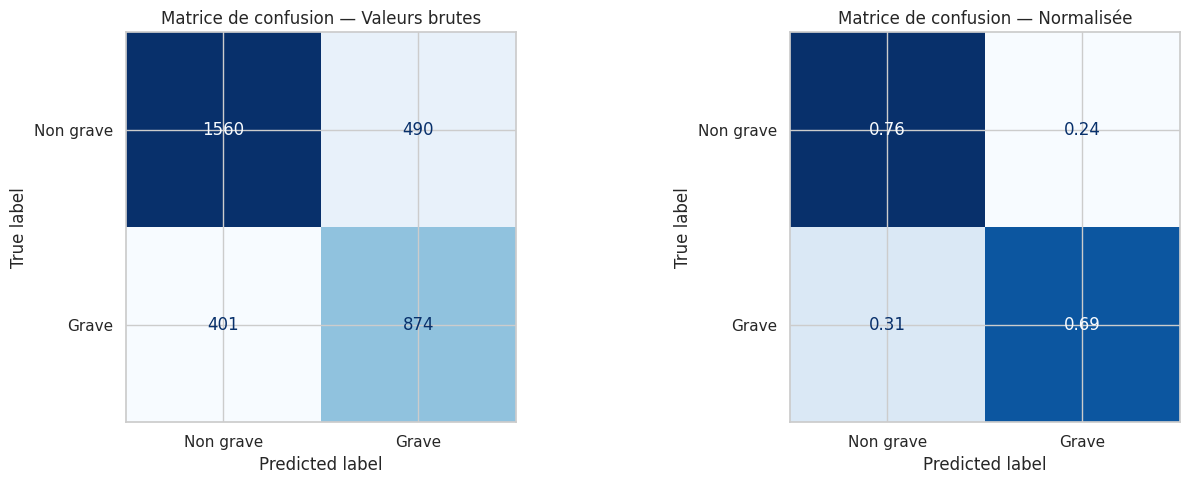

Comparaison des stratégies SVM pour le déséquilibre des classes


,Méthode,Recall (Grave),F1-Score,Précision,ROC AUC
0,SVM (class_weight=balanced),0.75,0.68,0.62,0.80
1,SVM (SMOTE),0.69,0.66,0.64,0.79


In [ ]:
# Test complémentaire : SVM SMOTE vs class_weight

# Entraînement SVM sur données SMOTE
svm_baseline_smot = SVC(
    kernel='rbf', C=1.0, gamma='scale',
    probability=True, random_state=42
)

print("Entraînement SVM + SMOTE en cours...")
start = time.time()
svm_baseline_smot.fit(X_train_sm_sc, y_train_sm)
end = time.time()
print(f"Temps d'entraînement : {end - start:.1f} secondes")

# Prédictions, X_test_sc (normalisé)
y_pred_svm_smot  = svm_baseline_smot.predict(X_test_sc)
y_proba_svm_smot = svm_baseline_smot.predict_proba(X_test_sc)[:, 1]

# Rapport de classification
print("\nRapport de classification — SVM SMOTE")
print(classification_report(
    y_test, y_pred_svm_smot,
    target_names=['Non grave (0)', 'Grave (1)']
))
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_proba_svm_smot):.4f}")

# Matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_svm_smot)
ConfusionMatrixDisplay(cm, display_labels=['Non grave', 'Grave']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de confusion — Valeurs brutes')

cm_norm = confusion_matrix(y_test, y_pred_svm_smot, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=['Non grave', 'Grave']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matrice de confusion — Normalisée')

plt.tight_layout()
plt.show()

# Tableau comparatif SMOTE vs class_weight sur SVM
# svm_base = modèle baseline class_weight défini en 10.7
configs = [
    {'nom': 'SVM (class_weight=balanced)', 'model': svm_base,           'X': X_test_sc},
    {'nom': 'SVM (SMOTE)',                 'model': svm_baseline_smot,  'X': X_test_sc},
]

results_svm = []
for config in configs:
    yp = config['model'].predict(config['X'])
    results_svm.append({
        'Méthode'       : config['nom'],
        'Recall (Grave)': round(recall_score(y_test, yp), 4),
        'F1-Score'      : round(f1_score(y_test, yp), 4),
        'Précision'     : round(precision_score(y_test, yp), 4),
        'ROC AUC'       : round(roc_auc_score(y_test, config['model'].predict_proba(config['X'])[:, 1]), 4),
    })

df_comparaison_svm = pd.DataFrame(results_svm)
print("Comparaison des stratégies SVM pour le déséquilibre des classes")
display(df_comparaison_svm)

**Stratégie retenue : `class_weight='balanced'` sans SMOTE**

On a testé trois façons de gérer le déséquilibre 38%/62% :
- **SMOTE** : crée de faux accidents graves pour rééquilibrer artificiellement.
  Ici le déséquilibre est trop faible pour en bénéficier — les données synthétiques
  perturbent le modèle sans apporter de signal réel.
- **`class_weight='balanced'`** : dit au modèle de donner plus de poids aux accidents
  graves pendant l'apprentissage, sans toucher aux données. Donne le meilleur recall.
- **Sans correction** : le modèle ignore le déséquilibre et rate davantage de graves.

→ `class_weight='balanced'` sera appliqué à la LR et au SVM.  
→ Pour RF et XGBoost : paramètre équivalent disponible (`scale_pos_weight` pour XGBoost).

###**10.4 Regression Logistique (baseline)**

In [ ]:
# Travaille sur X_train_sc / X_test_sc (données normalisées)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

print("Régression Logistique")
print(f"Recall grave : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-score     : {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC AUC      : {roc_auc_score(y_test, y_prob_lr):.4f}")

Régression Logistique
Recall grave : 0.7404
F1-score     : 0.6721
ROC AUC      : 0.7970


###**10.5 Random Forest (baseline -> tuning -> final)**

#### Pourquoi Random Forest ?

L'EDA a montré que les facteurs de risque agissent par seuils, pas de façon linéaire : hors agglomération c'est 70% de graves contre 29% en ville, la nuit sans éclairage monte à 63% contre 25% la nuit éclairée, et les seniors sont surreprésentés dans les accidents mortels. Un modèle linéaire ne capte pas ces ruptures alors que RF oui, en découpant naturellement l'espace des features à chaque split.

Le dataset est déséquilibré (38% graves) : class_weight='balanced' (commenté car SMOTE nous donne le même résultat) compense ça sans toucher aux données.

Stratégie envisagée :

On entraîne d'abord un RF avec les paramètres par défaut pour avoir un point de référence, puis on cherche les meilleurs hyperparamètres avec RandomizedSearchCV, plutôt que GridSearchCV qui teste toutes les combinaisons, RandomizedSearchCV en tire un échantillon aléatoire, ce qui est beaucoup plus rapide sur un espace de features large où 30 itérations aléatoires couvrent généralement assez bien.

##### ***1. Baseline***

RF avec paramètres par défaut, cela va nous servir de référence pour mesurer le gain du tuning.

In [ ]:
rf_base = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_base.fit(X_train, y_train)

y_pred_rf_base = rf_base.predict(X_test)
print(f"Baseline RF — Recall : {recall_score(y_test, y_pred_rf_base):.4f} | "
      f"ROC AUC : {roc_auc_score(y_test, rf_base.predict_proba(X_test)[:,1]):.4f}")

Baseline RF — Recall : 0.6361 | ROC AUC : 0.8156


constats : Recall de 0.64 sur 100 accidents graves, le modèle en rate 36. C'est notre point de départ plutôt acceptable mais le tuning devrait améliorer ça.

ROC AUC de 0.82 : le modèle distingue bien graves et non-graves dans l'ensemble, indépendamment du seuil de décision. C'est déjà un bon signal pour un dataset avec des corrélations faibles.

---

#####***2. Tuning***

RandomizedSearchCV sur 5 folds, 30 itérations, scoring = recall (classe grave). Plus rapide que GridSearchCV sur plusieures features, couvre l'espace des hyperparamètres de façon aléatoire.

In [ ]:
# Commenté car long à exécuter, résultats déjà récupérés ci-dessous

# param_dist_rf = {
#     'n_estimators'     : [100, 200, 300, 500],
#     'max_depth'        : [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf' : [1, 2, 4],
#     'max_features'     : ['sqrt', 'log2', 0.2, 0.3],
# }

# search_rf = RandomizedSearchCV(
#     RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
#     param_distributions=param_dist_rf,
#     n_iter=30, cv=5, scoring='recall',
#     n_jobs=-1, random_state=42, verbose=1
# )
# search_rf.fit(X_train, y_train)
# print(f"Meilleurs hyperparamètres RF : {search_rf.best_params_}")
# print(f"Recall CV (train)            : {search_rf.best_score_:.4f}")

#####***3. Modèle Final***

In [ ]:
rf_final = RandomForestClassifier(
    n_estimators=300, # meilleur hyperparamètre issu du tuning
    max_depth=30, # meilleur hyperparamètre issu du tuning
    min_samples_split=10, # meilleur hyperparamètre issu du tuning
    min_samples_leaf=1, # meilleur hyperparamètre issu du tuning
    max_features='sqrt', # meilleur hyperparamètre issu du tuning
    class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_final.fit(X_train, y_train)

y_pred_rf = rf_final.predict(X_test)
y_prob_rf  = rf_final.predict_proba(X_test)[:, 1]

print(f"Final RF — Recall : {recall_score(y_test, y_pred_rf):.4f} | "
      f"ROC AUC : {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"Gain recall vs baseline : {recall_score(y_test, y_pred_rf) - recall_score(y_test, y_pred_rf_base):+.4f}")

Final RF — Recall : 0.7255 | ROC AUC : 0.8218
Gain recall vs baseline : +0.0894


###**10.6 XGBoost (baseline -> tuning -> final)**

#### Pourquoi XGBoost ?

Le Random Forest construit ses arbres en parallèle et de façon indépendante. XGBoost (eXtreme Gradient Boosting) prend le chemin inverse : il construit les arbres **en séquence**, chaque nouvel arbre corrigeant les erreurs du précédent. C'est ce mécanisme de **boosting** qui lui donne un avantage sur les données tabulaires avec des patterns complexes.

Autres avantages pour notre cas :
- `learning_rate` + `n_estimators` : contrôle fin du compromis biais/variance
- La courbe de loss sur le jeu de test permet de détecter l'overfitting arbre par arbre

**Stratégie : Baseline -> Tuning -> Final** (même démarche que le Random Forest pour pouvoir comparer les gains)



In [ ]:
# Travaille sur X_train / X_test (pas besoin de normalisation pour XGBoost)
# scale_pos_weight = ratio négatifs/positifs = équivalent de class_weight='balanced'

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos

#####***1. Baseline***

In [ ]:
xgb_base = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=spw,
    eval_metric='logloss',
    random_state=42, n_jobs=-1
)
xgb_base.fit(X_train, y_train)

y_pred_xgb_base = xgb_base.predict(X_test)
print(f"Baseline XGB — Recall : {recall_score(y_test, y_pred_xgb_base):.4f} | "
      f"ROC AUC : {roc_auc_score(y_test, xgb_base.predict_proba(X_test)[:,1]):.4f}")

Baseline XGB — Recall : 0.7459 | ROC AUC : 0.8022


**Constats baseline :**

Le recall et le ROC AUC nous donnent notre point de départ. Comme pour le RF, le recall est notre métrique prioritaire MAIS on surveille aussi le ROC AUC pour s'assurer que le tuning améliore le pouvoir discriminant global et pas seulement le seuil de décision.

---


#####***2. Tuning***

In [ ]:
# Commenté car long à exécuter,résultats déjà récupérés ci-dessous

# param_dist_xgb = {
#     'n_estimators'    : [100, 200, 300, 500],
#     'max_depth'       : [3, 4, 5, 6, 8],
#     'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
#     'subsample'       : [0.6, 0.7, 0.8, 1.0],
#     'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
#     'min_child_weight': [1, 3, 5, 10],
# }

# search_xgb = RandomizedSearchCV(
#     XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=42, n_jobs=-1),
#     param_distributions=param_dist_xgb,
#     n_iter=30, cv=5, scoring='recall',
#     n_jobs=-1, random_state=42, verbose=1
# )
# search_xgb.fit(X_train, y_train)
# print(f"Meilleurs hyperparamètres XGB : {search_xgb.best_params_}")
# print(f"Recall CV (train)             : {search_xgb.best_score_:.4f}")

#####***3. Modèle final***

In [ ]:
# Meilleurs hyperparamètres issus du tuning
xgb_final = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    scale_pos_weight=spw,
    eval_metric='logloss',
    random_state=42, n_jobs=-1
)
xgb_final.fit(X_train, y_train)

y_pred_xgb = xgb_final.predict(X_test)
y_prob_xgb  = xgb_final.predict_proba(X_test)[:, 1]

print(f"Final XGB — Recall : {recall_score(y_test, y_pred_xgb):.4f} | "
      f"ROC AUC : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"Gain recall vs baseline XGB : {recall_score(y_test, y_pred_xgb) - recall_score(y_test, y_pred_xgb_base):+.4f}")
print(f"Gain recall vs RF final     : {recall_score(y_test, y_pred_xgb) - recall_score(y_test, y_pred_rf):+.4f}")


Final XGB — Recall : 0.7608 | ROC AUC : 0.8142
Gain recall vs baseline XGB : +0.0149
Gain recall vs RF final     : +0.0353


###**10.7 SVM (Support Vector Machine)**

#### Pourquoi SVM ?

Le SVM cherche l'**hyperplan de séparation à marge maximale** entre les deux classes. Contrairement au RF et à XGBoost qui agrègent un grand nombre d'arbres, le SVM raisonne globalement sur l'ensemble du dataset et produit une frontière de décision unique, déterministe et robuste face aux outliers (seuls les *support vectors* influencent la frontière).

Son atout principal ici : avec un **noyau RBF** (Radial Basis Function), il peut capturer des frontières non-linéaires sans que l'utilisateur ait à construire les interactions à la main — ce qui est précieux sur un espace de 131 features où les interactions conditionnelles sont nombreuses (ex : `hors_agglo_nuit`).

Son principal inconvénient : **il ne sort pas de probabilités calibrées nativement** (`probability=True` ajoute une calibration Platt, ce qui permet tout de même de tracer une courbe ROC). Il est aussi plus coûteux en calcul que les méthodes ensemblistes sur des datasets larges.

**Stratégie : Baseline -> Tuning -> Final** (même structure que RF et XGBoost pour garantir la comparabilité)

#####***1. Baseline***

In [ ]:
# Le baseline SVM (svm_base) a été entraîné en section 10.3 pour le tableau comparatif SMOTE vs class_weight, on le réutilise directement ici.

# Résultats baseline déjà disponibles :
# y_pred_svm_base / y_prob_svm_base


**Constats baseline SVM :**

Le SVM avec noyau RBF et paramètres par défaut nous donne un premier repère. Le recall et le ROC AUC sont à comparer à ceux de la LR et du RF baseline. La normalisation est ici **critique** : sans `StandardScaler`, le SVM donnerait des résultats arbitraires car il est très sensible à l'échelle des features — c'est pourquoi on réutilise `X_train_sc` et `X_test_sc` déjà normalisés pour la régression logistique.

#####***2. Tuning***

Le SVM a deux hyperparamètres principaux :
- **`C`** (régularisation) : fort C = modèle plus complexe, risque d'overfitting ; faible C = marge plus large, modèle plus robuste
- **`gamma`** (portée du noyau RBF) : fort gamma = frontière très localisée (overfitting) ; faible gamma = frontière lisse

On cherche le meilleur compromis C/gamma via `RandomizedSearchCV` avec le même scoring recall que pour RF et XGBoost. On limite à 20 itérations car le SVM est significativement plus lent que les méthodes ensemblistes sur des datasets avec de nombreuses features.

In [ ]:
# Commenté car long à exécuter, résultats déjà récupérés ci-dessous)

# param_dist_svm = {
#     'C'    : loguniform(0.1, 100),
#     'gamma': loguniform(1e-4, 1e-1),
# }

# search_svm = RandomizedSearchCV(
#     SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
#     param_distributions=param_dist_svm,
#     n_iter=20, cv=5, scoring='recall',
#     n_jobs=-1, random_state=42, verbose=1
# )
# search_svm.fit(X_train_sc, y_train)
# print(f"Meilleurs hyperparamètres SVM : {search_svm.best_params_}")
# print(f"Recall CV (train)             : {search_svm.best_score_:.4f}")

#####***3. Modèle SVM final***

In [ ]:
# meilleurs hyperparamètres issus du tuning
svm_final = SVC(
    kernel='rbf',
    C=1.0,
    gamma=0.01,
    probability=True,
    class_weight='balanced',
    random_state=42
)
svm_final.fit(X_train_sc, y_train)

y_pred_svm = svm_final.predict(X_test_sc)
y_prob_svm = svm_final.predict_proba(X_test_sc)[:, 1]

print(f"Final SVM — Recall : {recall_score(y_test, y_pred_svm):.4f} | "
      f"ROC AUC : {roc_auc_score(y_test, y_prob_svm):.4f}")
print(f"Gain recall vs baseline SVM : {recall_score(y_test, y_pred_svm) - recall_score(y_test, y_pred_svm_base):+.4f}")

Final SVM — Recall : 0.6784 | ROC AUC : 0.7699
Gain recall vs baseline SVM : -0.0690


##**11. Evaluation & comparaison des modèles**

On compare ici l'ensemble des modèles finaux (post-tuning) sur le jeu de test. Le recall sur la classe grave est notre **métrique prioritaire** : rater un accident grave a des conséquences bien plus lourdes qu'un faux positif. On suit aussi le F1-score (compromis précision/recall) et le ROC AUC (pouvoir discriminant global, indépendant du seuil).

In [ ]:
# Tous les modèles utilisent leurs propres données (normalisées ou non) mais sont évalués sur le MÊME y_test

models_eval = {
    'Logistic Regression': {'pred': y_pred_lr,  'prob': y_prob_lr},
    'Random Forest':       {'pred': y_pred_rf,  'prob': y_prob_rf},
    'XGBoost':             {'pred': y_pred_xgb, 'prob': y_prob_xgb},
    'SVM':                 {'pred': y_pred_svm, 'prob': y_prob_svm},
}

rows = []
for name, m in models_eval.items():
    rows.append({
        'Modèle'        : name,
        'Accuracy'      : round(accuracy_score(y_test, m['pred']), 4),
        'Précision'     : round(precision_score(y_test, m['pred']), 4),
        'Recall (grave)': round(recall_score(y_test, m['pred']), 4),
        'F1-score'      : round(f1_score(y_test, m['pred']), 4),
        'ROC AUC'       : round(roc_auc_score(y_test, m['prob']), 4),
    })

df_results = pd.DataFrame(rows).set_index('Modèle')
print("Tableau comparatif des modèles (trié par Recall grave) :")
display(df_results.sort_values('Recall (grave)', ascending=False))

Tableau comparatif des modèles (trié par Recall grave) :


,Accuracy,Précision,Recall (grave),F1-score,ROC AUC
Modèle,,,,,
XGBoost,0.73,0.63,0.76,0.69,0.81
Logistic Regression,0.72,0.62,0.74,0.67,0.80
Random Forest,0.75,0.65,0.73,0.69,0.82
SVM,0.70,0.60,0.68,0.64,0.77


- XGBoost meilleur recall (76%), Random Forest meilleur ROC AUC (0.822) et meilleure précision (65%).
- La LR surprend avec un recall de 74% malgré sa simplicité — le feature engineering paie.
- Le SVM est en retrait sur toutes les métriques

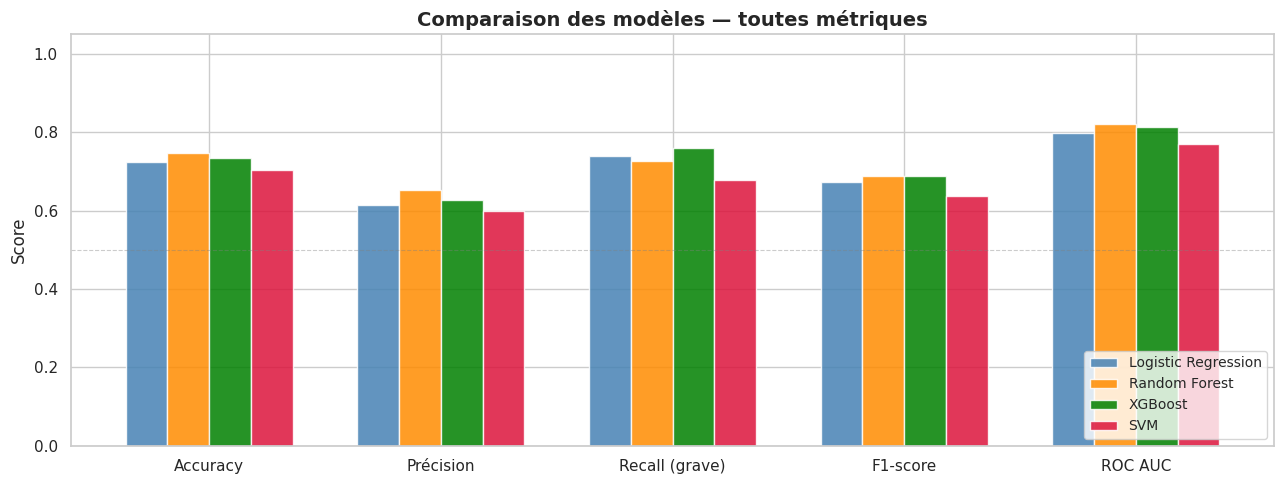

In [ ]:
# Visualisation : comparaison des métriques
metriques = ['Accuracy', 'Précision', 'Recall (grave)', 'F1-score', 'ROC AUC']
couleurs   = ['steelblue', 'darkorange', 'green', 'crimson']

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(metriques))
width = 0.18

for i, (name, row) in enumerate(df_results.iterrows()):
    vals = [row[m] for m in metriques]
    ax.bar(x + i * width, vals, width, label=name, color=couleurs[i], alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metriques, fontsize=11)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)
ax.set_title("Comparaison des modèles — toutes métriques", fontsize=14, fontweight='bold')
ax.set_ylabel("Score")
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

Les 4 modèles sont très proches sur le recall (8 points d'écart max entre XGBoost et SVM).
Les écarts se creusent sur la précision et le ROC AUC. La précision est systématiquement
plus basse que le recall sur tous les modèles, effet direct du class_weight='balanced'.

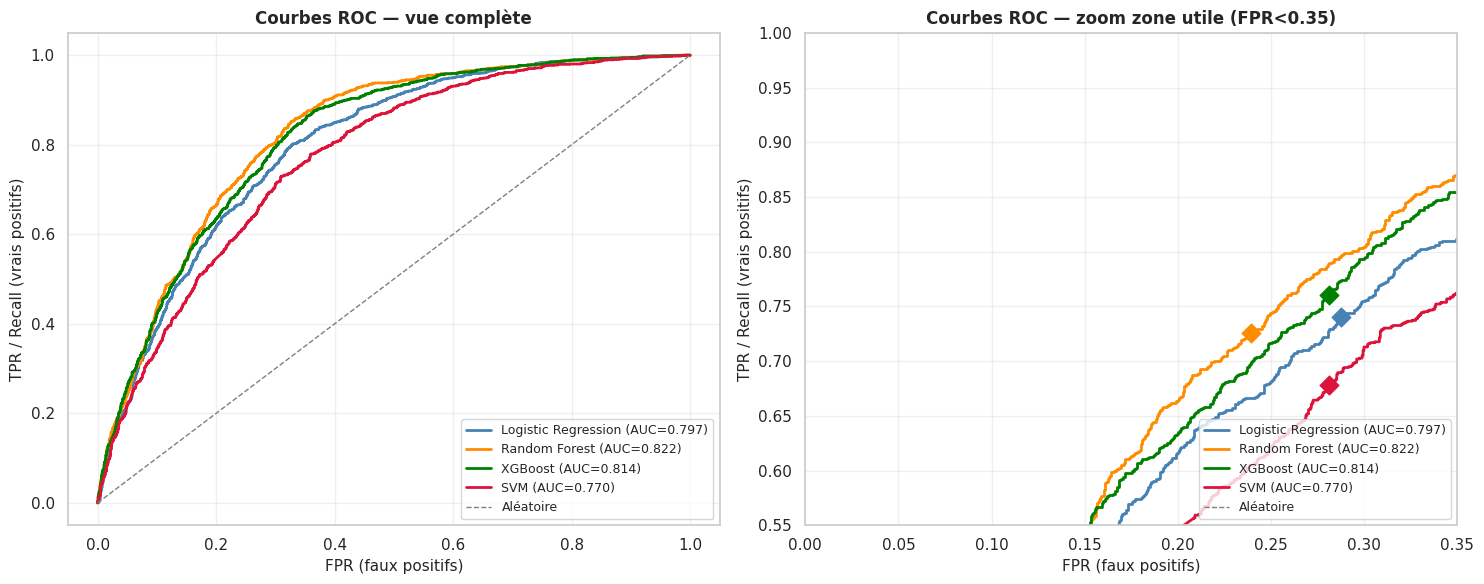

In [ ]:
# Courbes ROC + zoom zone utile
couleurs = ['steelblue', 'darkorange', 'green', 'crimson']
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for (name, m), color in zip(models_eval.items(), couleurs):
    fpr, tpr, _ = roc_curve(y_test, m['prob'])
    auc = roc_auc_score(y_test, m['prob'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, linewidth=2)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, linewidth=2)

for ax in axes:
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Aléatoire')
    ax.set_xlabel('FPR (faux positifs)', fontsize=11)
    ax.set_ylabel('TPR / Recall (vrais positifs)', fontsize=11)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)

axes[0].set_title("Courbes ROC — vue complète", fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 0.35); axes[1].set_ylim(0.55, 1.0)
axes[1].set_title("Courbes ROC — zoom zone utile (FPR<0.35)", fontsize=12, fontweight='bold')

# Points de fonctionnement au seuil 0.5
for (name, m), color in zip(models_eval.items(), couleurs):
    pred = m['pred']
    fpr_pt = float((pred[y_test == 0] == 1).mean())
    tpr_pt = float((pred[y_test == 1] == 1).mean())
    axes[1].scatter(fpr_pt, tpr_pt, color=color, s=90, zorder=5, marker='D')

plt.tight_layout()
plt.show()

RF (AUC=0.822) et XGBoost (AUC=0.814) dominent, LR (0.797) et SVM (0.770) derrière.
Tous très au-dessus de l'aléatoire. Sur le zoom, RF garde un avantage sur XGBoost à
faible taux de faux positifs, il est plus sélectif quand on veut limiter les fausses alarmes.

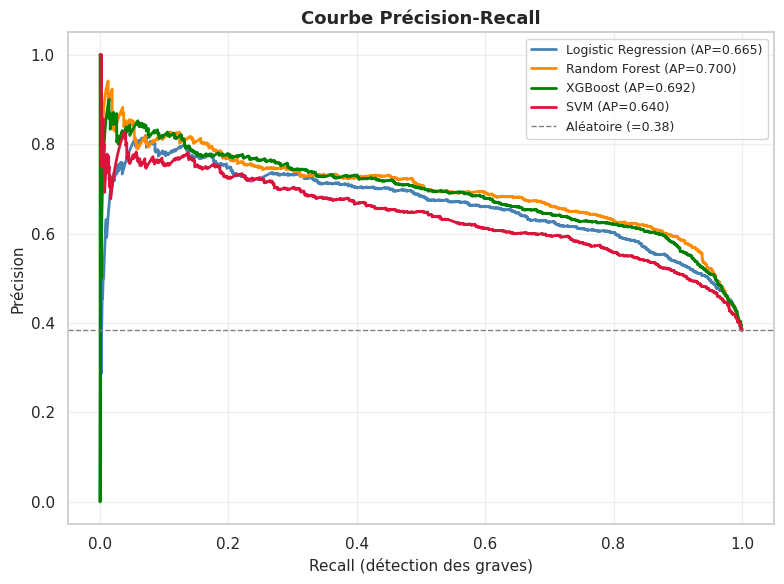

In [ ]:
# Courbe Précision-Recall
from sklearn.metrics import average_precision_score

fig, ax = plt.subplots(figsize=(8, 6))
for (name, m), color in zip(models_eval.items(), couleurs):
    prec, rec, _ = precision_recall_curve(y_test, m['prob'])
    ap = average_precision_score(y_test, m['prob'])
    ax.plot(rec, prec, label=f"{name} (AP={ap:.3f})", color=color, linewidth=2)

baseline_rate = float(y_test.mean())
ax.axhline(baseline_rate, color='gray', linestyle='--', linewidth=1,
           label=f'Aléatoire (={baseline_rate:.2f})')
ax.set_xlabel('Recall (détection des graves)', fontsize=11)
ax.set_ylabel('Précision', fontsize=11)
ax.set_title("Courbe Précision-Recall", fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Tous les modèles largement au-dessus du hasard (0.38). RF meilleure AP (0.700), XGBoost
(0.692). Les 4 courbes sont proches en dessous de 0.4 de recall, les différences
apparaissent surtout à partir de 0.5 de recall où RF et XGBoost maintiennent une
meilleure précision.

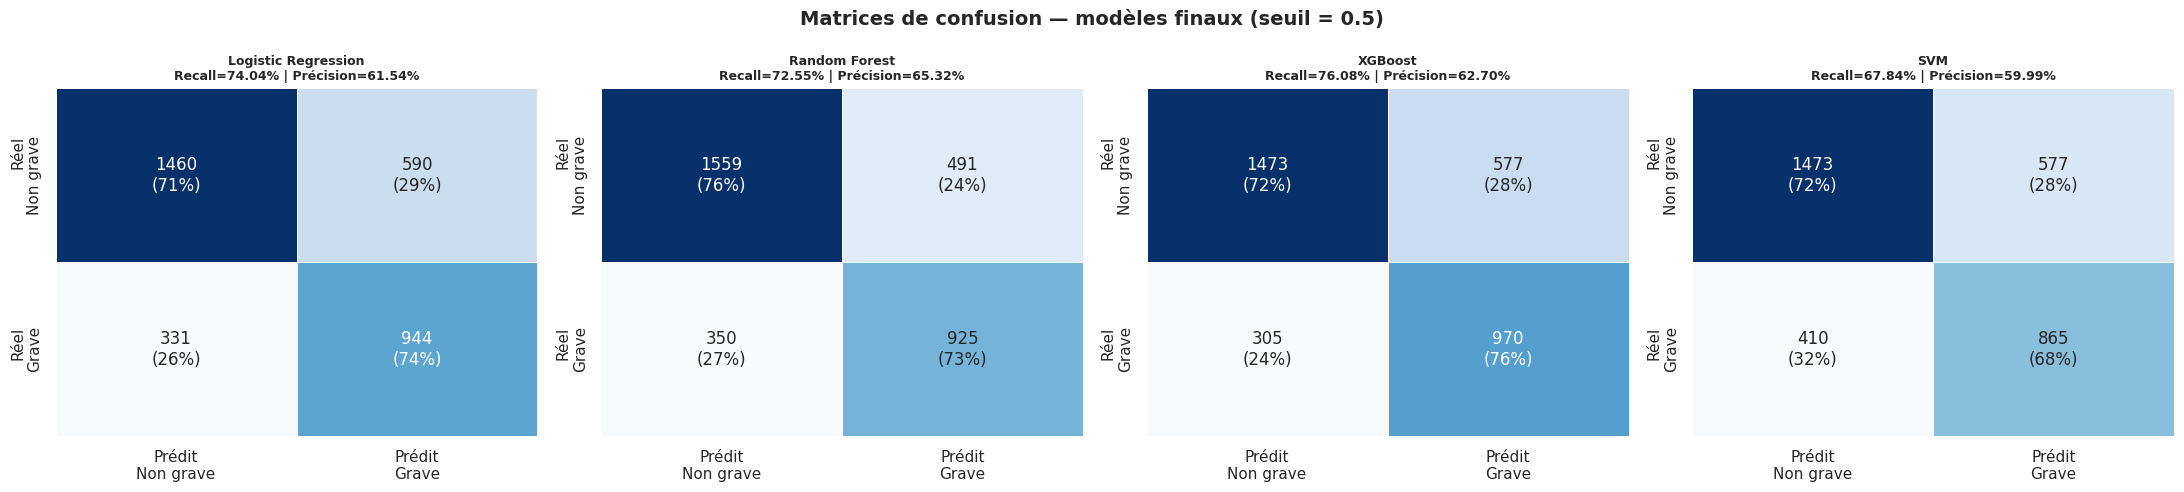

FN = graves ratés (coût humain élevé) | FP = fausses alarmes (coût administratif)

  Logistic Regression    → FN: 331 graves ratés | FP:  590 fausses alarmes | TP: 944
  Random Forest          → FN: 350 graves ratés | FP:  491 fausses alarmes | TP: 925
  XGBoost                → FN: 305 graves ratés | FP:  577 fausses alarmes | TP: 970
  SVM                    → FN: 410 graves ratés | FP:  577 fausses alarmes | TP: 865


In [ ]:
# Matrices de confusion avec effectifs ET pourcentages
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("Matrices de confusion — modèles finaux (seuil = 0.5)", fontsize=14, fontweight='bold')

for ax, (name, m), color in zip(axes, models_eval.items(), couleurs):
    cm = confusion_matrix(y_test, m['pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = [[f"{cm[i,j]}\n({cm_pct[i,j]:.0f}%)" for j in range(2)] for i in range(2)]
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=['Prédit\nNon grave', 'Prédit\nGrave'],
                yticklabels=['Réel\nNon grave', 'Réel\nGrave'],
                linewidths=0.5, cbar=False)
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{name}\nRecall={tp/(tp+fn):.2%} | Précision={tp/(tp+fp) if (tp+fp)>0 else 0:.2%}",
                 fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("FN = graves ratés (coût humain élevé) | FP = fausses alarmes (coût administratif)")
print()
for name, m in models_eval.items():
    tn, fp, fn, tp = confusion_matrix(y_test, m['pred']).ravel()
    print(f"  {name:<22} → FN: {fn:3d} graves ratés | FP: {fp:4d} fausses alarmes | TP: {tp:3d}")


Sur 1 275 accidents graves, XGBoost en rate 305 (24%), LR 331 (26%), RF 350 (27%),
SVM 410 (32%).

Ces accidents ratés sont le vrai coût humain du modèle. RF compense
avec moins de fausses alarmes (491 vs environ 577 pour les autres).

In [ ]:
# Seuil de décision optimal (F1-score)
print("Recherche du seuil de décision optimal (max F1)\n")
print(f"{'Modèle':<22} {'Seuil opt':>10} {'Recall':>10} {'Précision':>11} {'F1@opt':>9} {'F1@0.5':>9}")
print('-' * 76)

rows_seuil = []
for name, m in models_eval.items():
    prec_a, rec_a, thr_a = precision_recall_curve(y_test, m['prob'])
    f1_a = 2 * prec_a[:-1] * rec_a[:-1] / (prec_a[:-1] + rec_a[:-1] + 1e-9)
    best_idx = int(np.argmax(f1_a))
    bt = float(thr_a[best_idx])
    bp, br, bf = float(prec_a[best_idx]), float(rec_a[best_idx]), float(f1_a[best_idx])
    f1_05 = f1_score(y_test, m['pred'])
    print(f"{name:<22} {bt:>10.3f} {br:>10.4f} {bp:>11.4f} {bf:>9.4f} {f1_05:>9.4f}")
    rows_seuil.append({'Modèle': name, 'Seuil opt': round(bt,3),
                       'Recall@opt': round(br,4), 'Précision@opt': round(bp,4),
                       'F1@opt': round(bf,4), 'F1@0.5': round(f1_05,4)})

df_seuil = pd.DataFrame(rows_seuil).set_index('Modèle')
display(df_seuil)

Recherche du seuil de décision optimal (max F1)

Modèle                  Seuil opt     Recall   Précision    F1@opt    F1@0.5
----------------------------------------------------------------------------
Logistic Regression         0.449     0.8008      0.6027    0.6878    0.6721
Random Forest               0.382     0.8588      0.6155    0.7171    0.6875
XGBoost                     0.364     0.8761      0.5986    0.7112    0.6875
SVM                         0.295     0.8290      0.5505    0.6617    0.6367


,Seuil opt,Recall@opt,Précision@opt,F1@opt,F1@0.5
Modèle,,,,,
Logistic Regression,0.45,0.80,0.60,0.69,0.67
Random Forest,0.38,0.86,0.62,0.72,0.69
XGBoost,0.36,0.88,0.60,0.71,0.69
SVM,0.29,0.83,0.55,0.66,0.64


Le seuil 0.5 n'est pas optimal pour aucun des modèles. Seuils optimaux : LR=0.45,
RF=0.38, XGBoost=0.36, SVM=0.30. Tous en dessous de 0.5, les modèles sous-estiment
systématiquement la probabilité de gravité, baisser le seuil est donc toujours bénéfique.

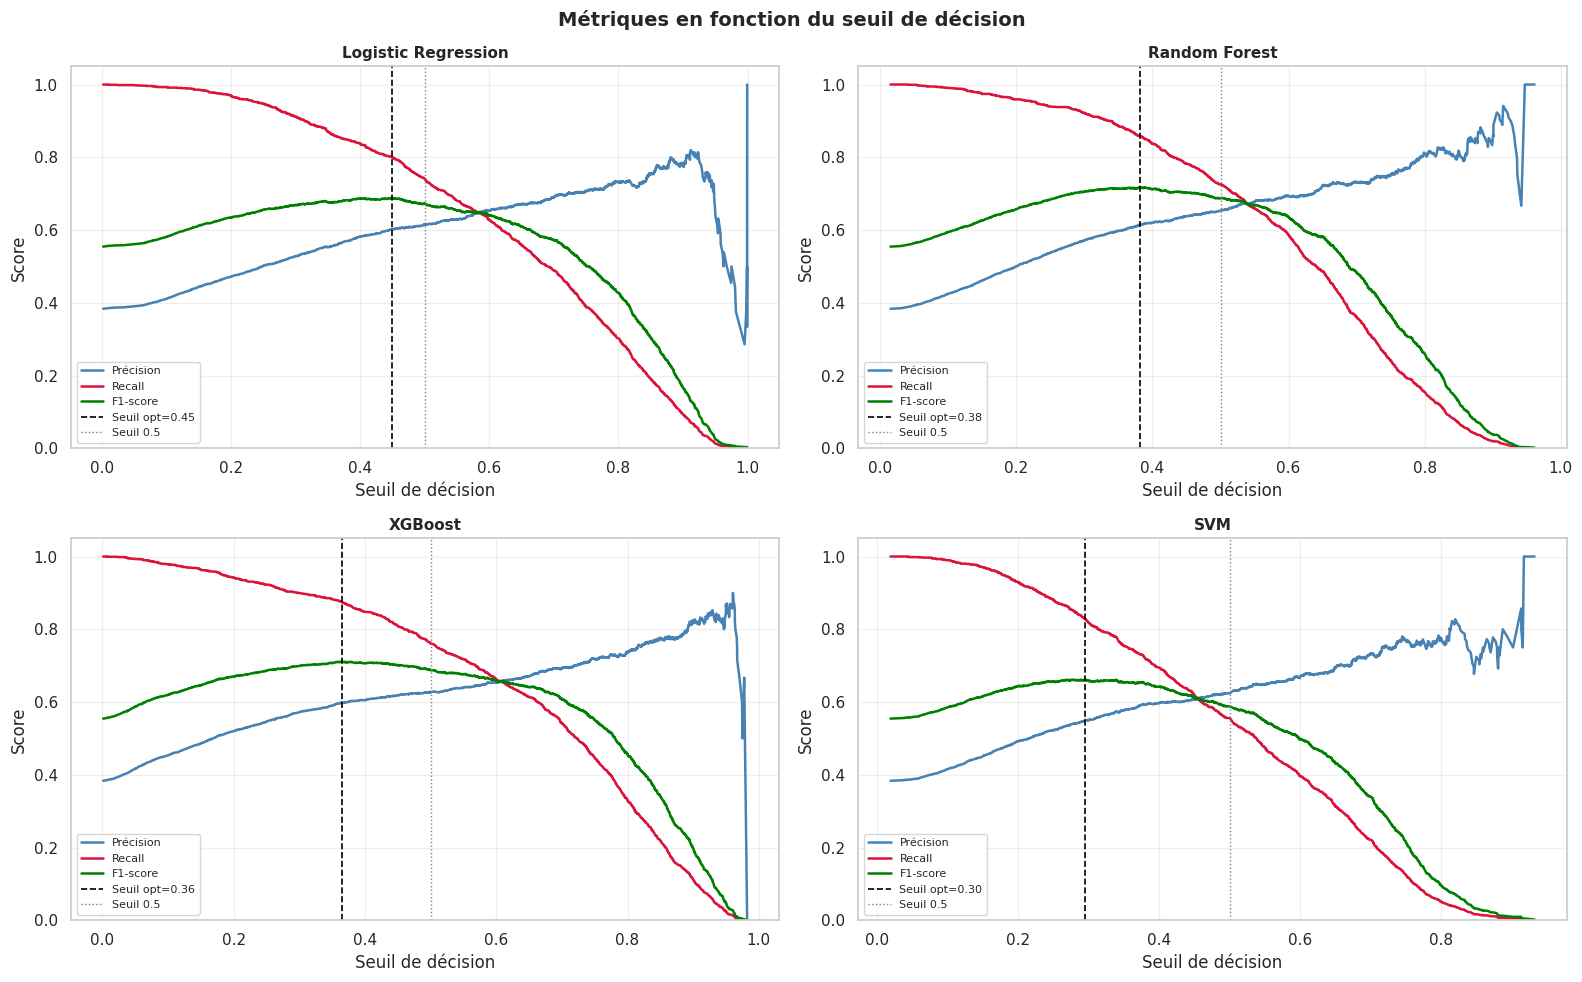

In [ ]:
# Évolution F1 / Recall / Précision selon le seuil
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Métriques en fonction du seuil de décision", fontsize=14, fontweight='bold')

for ax, (name, m), color in zip(axes.flat, models_eval.items(), couleurs):
    prec_a, rec_a, thr_a = precision_recall_curve(y_test, m['prob'])
    f1_a = 2 * prec_a[:-1] * rec_a[:-1] / (prec_a[:-1] + rec_a[:-1] + 1e-9)
    best_thr = float(thr_a[int(np.argmax(f1_a))])

    ax.plot(thr_a, prec_a[:-1], label='Précision', color='steelblue', linewidth=1.8)
    ax.plot(thr_a, rec_a[:-1],  label='Recall',    color='crimson',   linewidth=1.8)
    ax.plot(thr_a, f1_a,        label='F1-score',  color='green',     linewidth=1.8)
    ax.axvline(best_thr, color='black', linestyle='--', linewidth=1.2, label=f'Seuil opt={best_thr:.2f}')
    ax.axvline(0.5,      color='gray',  linestyle=':',  linewidth=1.0, label='Seuil 0.5')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Seuil de décision')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

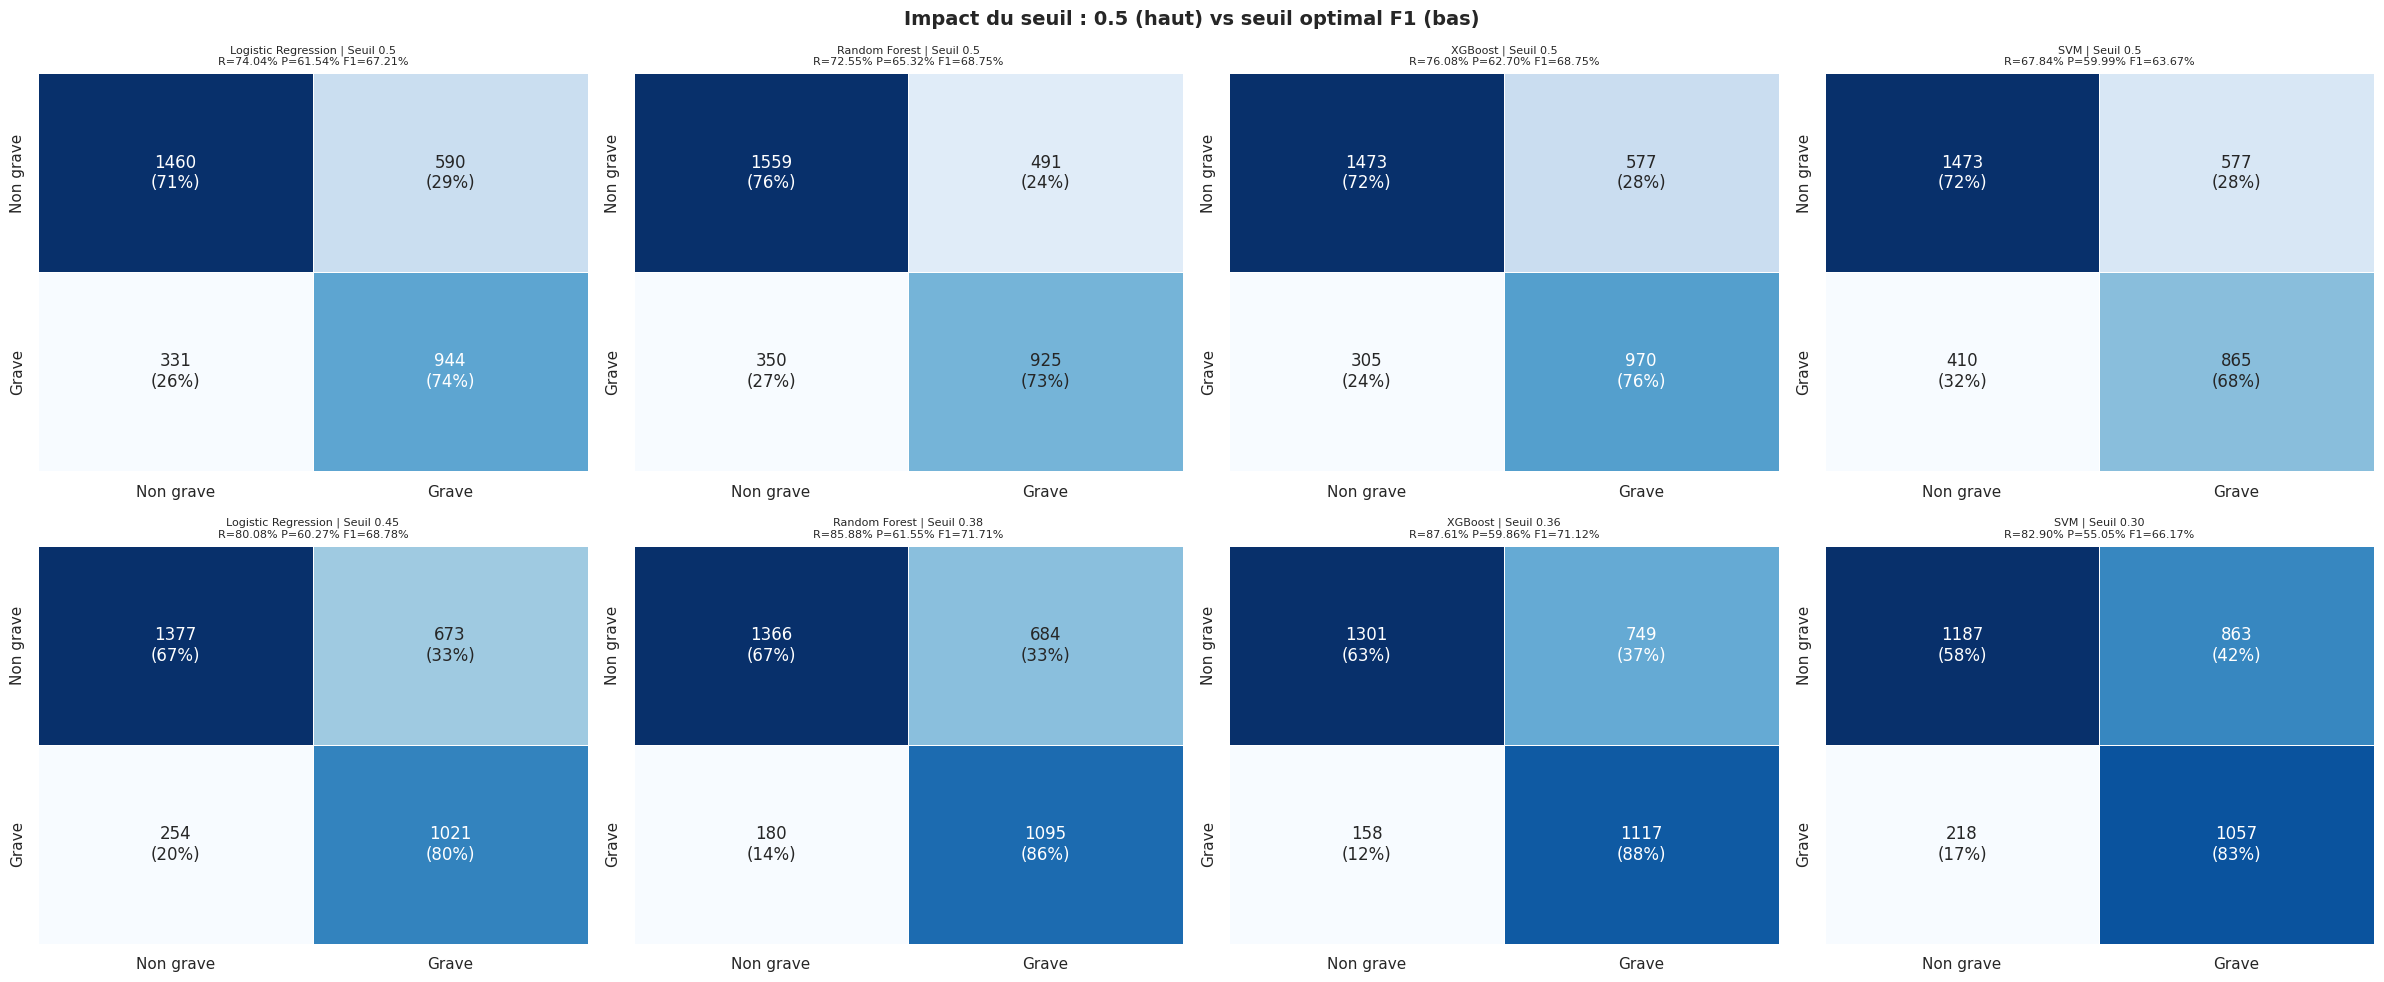

In [ ]:
# Matrices de confusion : seuil 0.5 vs seuil optimal
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle("Impact du seuil : 0.5 (haut) vs seuil optimal F1 (bas)", fontsize=14, fontweight='bold')

for col, (name, m) in enumerate(models_eval.items()):
    prec_a, rec_a, thr_a = precision_recall_curve(y_test, m['prob'])
    f1_a = 2 * prec_a[:-1] * rec_a[:-1] / (prec_a[:-1] + rec_a[:-1] + 1e-9)
    best_thr = float(thr_a[int(np.argmax(f1_a))])
    y_pred_opt = (m['prob'] >= best_thr).astype(int)

    for row, (pred_arr, lbl) in enumerate([(m['pred'], 'Seuil 0.5'), (y_pred_opt, f'Seuil {best_thr:.2f}')]):
        cm = confusion_matrix(y_test, pred_arr)
        tn, fp, fn, tp = cm.ravel()
        rec_v = tp/(tp+fn); prec_v = tp/(tp+fp) if (tp+fp)>0 else 0; f1_v = f1_score(y_test, pred_arr)
        cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
        annot = [[f"{cm[i,j]}\n({cm_pct[i,j]:.0f}%)" for j in range(2)] for i in range(2)]
        sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=axes[row, col],
                    xticklabels=['Non grave', 'Grave'], yticklabels=['Non grave', 'Grave'],
                    cbar=False, linewidths=0.5)
        axes[row, col].set_title(f"{name} | {lbl}\nR={rec_v:.2%} P={prec_v:.2%} F1={f1_v:.2%}", fontsize=8)

plt.tight_layout()
plt.show()

En passant au seuil optimal, XGBoost passe de 76% à 88% de recall, soit 147 graves
supplémentaires détectés. RF passe de 73% à 86%. Le prix à payer : plus de fausses alarmes
(les non graves bien classifiés chutent de 72% à 63% pour XGBoost). Arbitrage acceptable
dans un contexte santé publique.

In [ ]:
# Rapports de classification détaillé
print("Rapports de classification détaillés (seuil 0.5)")
for name, m in models_eval.items():
    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    print(classification_report(y_test, m['pred'], target_names=['Non grave', 'Grave']))

Rapports de classification détaillés (seuil 0.5)

───────────────────────────────────────────────────────
  Logistic Regression
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

   Non grave       0.82      0.71      0.76      2050
       Grave       0.62      0.74      0.67      1275

    accuracy                           0.72      3325
   macro avg       0.72      0.73      0.72      3325
weighted avg       0.74      0.72      0.73      3325


───────────────────────────────────────────────────────
  Random Forest
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

   Non grave       0.82      0.76      0.79      2050
       Grave       0.65      0.73      0.69      1275

    accuracy                           0.75      3325
   macro avg       0.73      0.74      0.74      3325
weighted avg       0.75      0.75      0.75      3325


────────────────────────────────

**Conclusion de l'évaluation**

Au seuil par défaut de 0.5, XGBoost ressort comme le meilleur modèle sur notre critère
prioritaire avec un recall de 76% et un ROC AUC de 0.814. Random Forest offre le meilleur
équilibre global (ROC AUC 0.822, précision 65%) mais détecte légèrement moins de graves (73%).
La Régression Logistique se montre étonnamment compétitive avec 74% de recall malgré sa
simplicité, ce qui valide la qualité du feature engineering. Le SVM reste en retrait avec
68% de recall et un ROC AUC de 0.770.

En abaissant les seuils de décision à leurs valeurs optimales, les performances s'améliorent
significativement : XGBoost atteint 88% de recall (seuil 0.36) et Random Forest 86%
(seuil 0.38), soit respectivement 147 et 170 accidents graves supplémentaires détectés
par rapport au seuil 0.5. Le prix à payer est une hausse des fausses alarmes,
mais dans un contexte de santé publique où rater un accident grave a des conséquences
humaines potentiellement irréversibles, cet arbitrage est pleinement justifié.

Pour une application concrète, on recommande XGBoost avec un seuil abaissé à 0.36
comme modèle de déploiement. Si la lisibilité et l'interprétabilité sont prioritaires,
la Régression Logistique reste une alternative solide dont les coefficients permettent
d'expliquer directement les facteurs de risque identifiés.

##**12. Interprétation & limites**

###12.1 Feature importance, quels facteurs expliquent la gravité ?

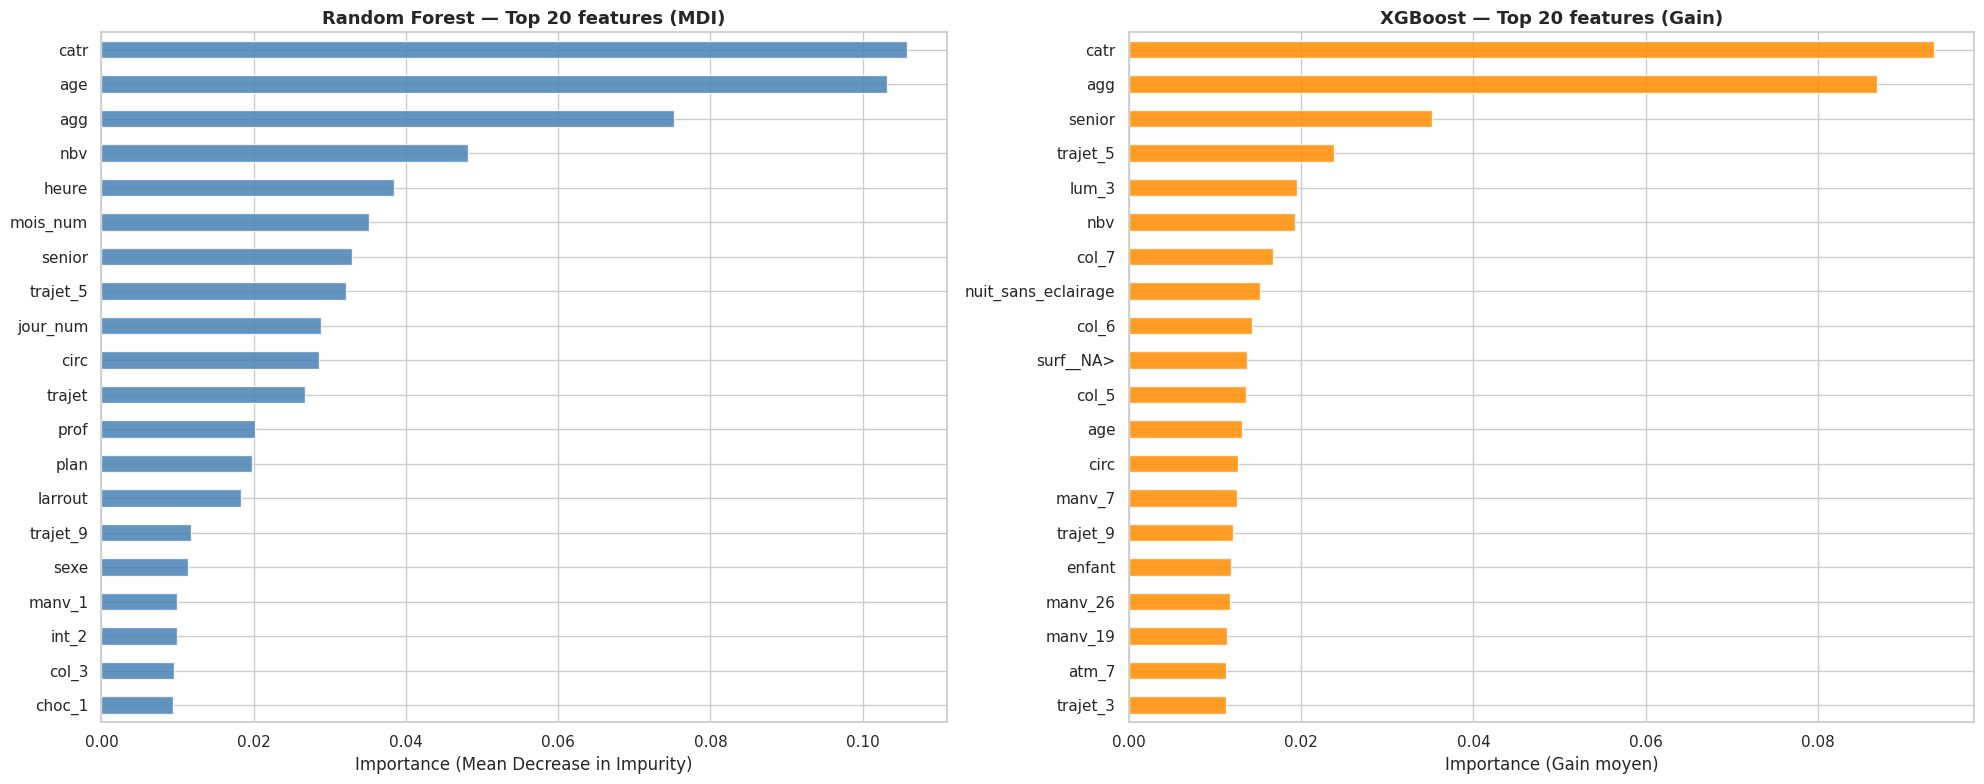

Features communes top 10 RF et XGBoost : {'senior', 'agg', 'nbv', 'catr', 'trajet_5'}


In [ ]:
# Feature importance RF + XGBoost
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

importances_rf = pd.Series(rf_final.feature_importances_, index=X.columns)
top20_rf = importances_rf.nlargest(20).sort_values()
top20_rf.plot(kind='barh', ax=axes[0], color='steelblue', alpha=0.85)
axes[0].set_title("Random Forest — Top 20 features (MDI)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Importance (Mean Decrease in Impurity)")

importances_xgb = pd.Series(xgb_final.feature_importances_, index=X.columns)
top20_xgb = importances_xgb.nlargest(20).sort_values()
top20_xgb.plot(kind='barh', ax=axes[1], color='darkorange', alpha=0.85)
axes[1].set_title("XGBoost — Top 20 features (Gain)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Importance (Gain moyen)")

plt.tight_layout()
plt.show()

top10_rf  = set(importances_rf.nlargest(10).index)
top10_xgb = set(importances_xgb.nlargest(10).index)
print(f"Features communes top 10 RF et XGBoost : {top10_rf & top10_xgb}")

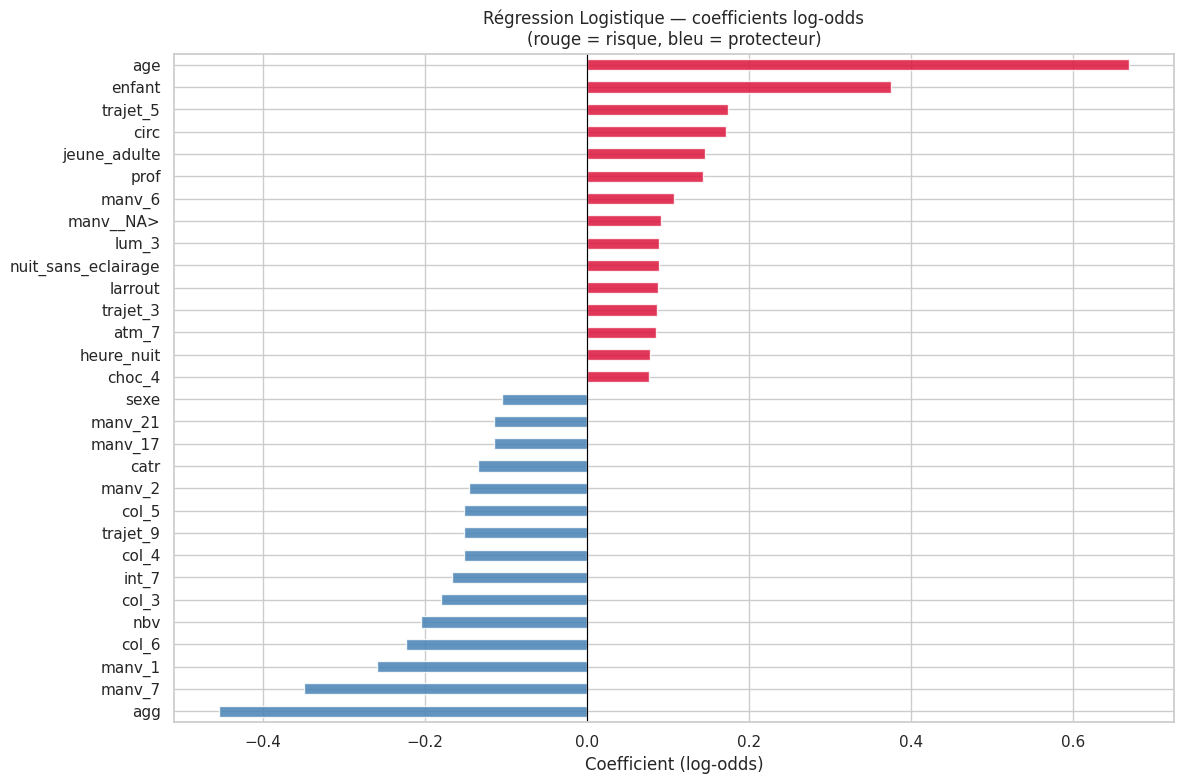

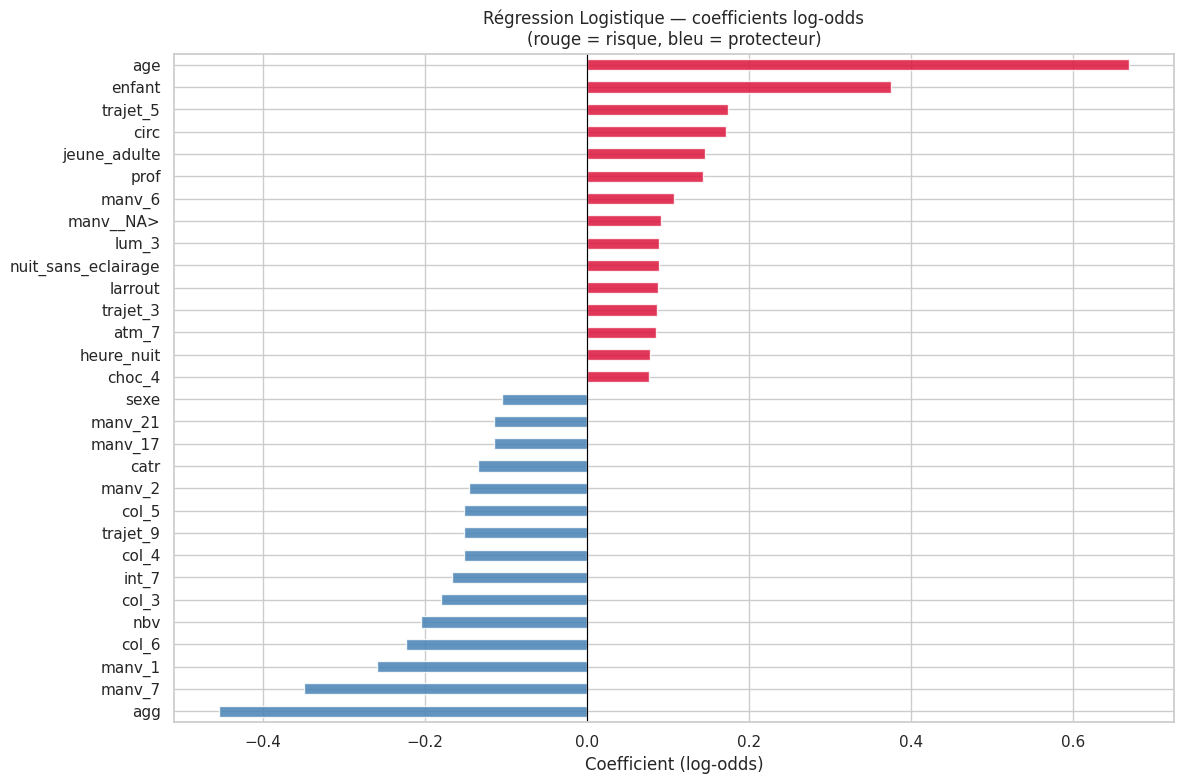

In [ ]:
# Coefficients Logistic Regression
coeff_lr = pd.Series(lr.coef_[0], index=X.columns)
top_lr = pd.concat([coeff_lr.nlargest(15), coeff_lr.nsmallest(15)]).sort_values()

fig, ax = plt.subplots(figsize=(12, 8))
colors_lr = ['crimson' if v > 0 else 'steelblue' for v in top_lr.values]
top_lr.plot(kind='barh', color=colors_lr, ax=ax, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Régression Logistique — coefficients log-odds\n(rouge = risque, bleu = protecteur)", fontsize=12)
ax.set_xlabel("Coefficient (log-odds)")
plt.tight_layout()
plt.show()

In [ ]:
# On prend un petit échantillon pour le background (sinon trop lent)
background = shap.sample(X_train_sc, 50)

explainer_svm = shap.KernelExplainer(svm_final.predict_proba, background)

# On explique seulement 50 observations du test (sinon trop long)
shap_values_svm = explainer_svm.shap_values(X_test_sc[:50])

# shap_values_svm[1] = classe grave
plt.figure()
shap.summary_plot(
    shap_values_svm[1],
    X_test_sc[:50],
    feature_names=X.columns,
    max_display=20,
    show=False
)
plt.title("SVM — SHAP values (impact sur la prédiction de gravité)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 1200x500 with 0 Axes>

### SHAP ; Analyse de l'interprétabilité du SVM

Le graphique SHAP Summary Plot ci-dessus permet de comprendre comment notre modèle SVM
prend ses décisions. Contrairement aux coefficients d'une régression logistique qui donnent
un impact global, SHAP calcule pour chaque observation l'influence de chaque variable sur
la prédiction : c'est ce qui en fait un outil d'interprétabilité plus précis.

**Hiérarchie des variables**

Sans surprise, `agg` (agglomération) et `age` ressortent en tête, ce qui est cohérent
avec tout ce qu'on a observé depuis l'EDA. Ce sont les 2 variables les plus
discriminantes du dataset, et le SVM les a bien identifiées comme telles de façon
indépendante. Certaines variables comme `atm_6` ou `col_4` présentent des points très
éloignés du centre malgré une faible fréquence, ça veut dire que quand elles sont
présentes, elles ont un impact fort sur la prédiction même si c'est rare.

**Direction de l'impact**

- `agg` : les points rouges (en agglomération) sont à gauche du zéro, le modèle a
  appris que la ville réduit la probabilité de gravité. Cohérent avec les vitesses
  plus basses et les secours plus rapides.
- `senior`, `enfant`, `nuit_sans_eclairage` : les points rouges partent vers la droite,
  ces variables augmentent le score de risque prédit. Ça confirme les patterns identifiés
  en section 7 et 6.

**Ce que ça dit du noyau RBF**

La distribution étalée et le chevauchement des couleurs pour `age` ou `catr` illustrent
bien pourquoi on a choisi un noyau RBF plutôt qu'un modèle linéaire. L'impact de l'âge
n'est pas une règle simple du type "plus on est vieux, plus c'est grave", il est modulé
par d'autres variables contextuelles. C'est exactement ce que le noyau RBF capture et
qu'une régression logistique ne pourrait pas reproduire sans construire les interactions
à la main.

---



Les features communes au top 10 RF et XGBoost sont les plus robustes, elles ressortent
indépendamment de la méthode, ce qui renforce leur crédibilité. L'analyse SHAP sur le
SVM converge vers les mêmes conclusions.

**`agg` (agglomération)** : variable la plus discriminante, en tête dans RF, XGBoost
et SHAP. Hors agglomération le taux de graves monte à environ 70% contre environ 29%
en ville.

**`catr` (catégorie de route)** : départementales et nationales concentrent les accidents
les plus mortels, cohérent avec `agg`.

**`heure` / `heure_nuit`** : la nuit entre 22h et 6h est le créneau le plus meurtrier.
Le matin entre 7h et 9h cumule volume ET gravité élevés.

**`age` / `senior`** : médiane d'environ 50 ans pour les graves contre environ 35 ans
pour les non graves, confirmé par Mann-Whitney en section 8 et par SHAP où les points
rouges de `senior` partent clairement vers la droite.

**`nuit_sans_eclairage`** : environ 63% de graves, ressort fortement dans RF, XGBoost
et SHAP, ce qui valide rétrospectivement le choix de l'avoir construite.

Au final, quatre approches différentes (RF, XGBoost, LR et SHAP sur SVM) pointent
vers les mêmes facteurs. Cette convergence est le résultat le plus solide du projet.

### 12.2 Limites & biais

**Biais de collecte**
- La rupture post-2018 dans le volume d'accidents reflète vraisemblablement un changement
  de périmètre ou de méthode de collecte, pas une baisse réelle de la sinistralité.
  Le filtre sur 2018+ réduit le dataset à ~16 600 lignes et limite le pouvoir statistique.

**Biais d'exposition**
- Le dataset compte les accidents, pas les cyclistes. Paris apparaît en tête des
  départements accidentogènes uniquement parce qu'il y a plus de cyclistes,
  pas parce que c'est plus dangereux. Sans données d'exposition (km parcourus,
  nombre de cyclistes), on ne peut pas calculer un taux de risque réel.

**Variables manquantes**
- La vitesse au moment de l'impact n'est pas disponible, c'est pourtant le facteur
  de gravité le plus documenté dans la littérature accidentologique.
- Le port du casque (`secuexist`) est présent mais très mal renseigné (~30% de NaN),
  ce qui limite son utilisation comme feature.

**Généralisation**
- Le modèle est entraîné sur 2018-2023. Les comportements cyclistes évoluent
  rapidement (explosion du vélo électrique, nouvelles infrastructures),
  les performances pourraient se dégrader sur des données plus récentes.
- Les features OHE génèrent 113 colonnes pour 16 600 lignes : risque de surapprentissage
  sur les modalités rares.

**Performance**
- Un recall de environ 75% sur la classe grave signifie qu'on rate encore 1 accident grave
  sur 4. Dans un contexte de santé publique, ce chiffre reste perfectible.
- Les quatre modèles convergent vers des performances proches, ce qui suggère que
  le plafond de performance est davantage lié à la qualité des données qu'au choix
  du modèle.

## **13. Pistes d'amélioration**


Le modèle qu'on a construit répond bien à la question posée, mais il y a plusieurs
directions qu'on aurait pu explorer avec plus de temps ou de données.

- Enrichir le dataset avec des données d'exposition (nombre de cyclistes par département,
km parcourus) permettrait de calculer un vrai taux de risque plutôt que de travailler
sur le volume brut d'accidents.
- Intégrer la vitesse limite de la voie comme proxy de
la vitesse d'impact comblerait une des limites les plus frustrantes du dataset.  
- On
aurait aussi pu tester des approches de stacking en combinant RF, XGBoost et LR pour
gratter quelques points de recall supplémentaires. Tester d'autres modèles comme
LightGBM ou CatBoost aurait pu être intéressant, ils sont souvent plus rapides et
aussi performants que XGBoost sur des données tabulaires comme évoquer lors du point ensemble.

- On aurait également pu aller plus loin sur l'analyse géographique en produisant une carte choroplèthe des taux de gravité par département, plutôt que de rester sur des barplots. Ça aurait rendu les résultats bien plus lisibles pour des décideurs publics et permis d'identifier visuellement des clusters territoriaux à risque, pas nécessaire à ce jour, au vu des délais nous avons priorisé d'autres choses.

- Enfin, réentraîner le modèle
annuellement serait important vu l'évolution rapide des comportements cyclistes,
explosion du vélo électrique et nouvelles infrastructures.

Une autre piste qu'on a pu testée concrètement : passer en classification multiclasse.

### 14.1 Classification multiclasse, challenge accepté

Jusqu'ici on a prédit grave vs non-grave. On s'est demandé ce que ça donnait si on
demandait au modèle de distinguer les 4 niveaux de gravité originaux : Indemne,
Blessé léger, Hospitalisé et Tué. Même features, même RF, seul y change.

Le vrai défi c'est que les tués représentent seulement 5.5% du dataset et les indemnes
7.4%, deux classes très minoritaires et pourtant les plus importantes à bien prédire.
On utilise SMOTE pour rééquilibrer les 4 classes et `f1_macro` comme métrique de scoring
pour forcer le modèle à performer sur chacune.

In [ ]:
# Cible multiclasse — même index que X
grav_labels = {1: 'Indemne', 2: 'Hospitalisé', 3: 'Tué', 4: 'Blessé léger'}

y_multi = df.loc[X.index, 'grav'].astype(int)

dist = y_multi.value_counts().sort_index()
print('Distribution de la cible multiclasse :')
for code_val, count in dist.items():
    print(f'  {grav_labels[code_val]:<18} ({code_val}) : {count:>5} — {count/len(y_multi)*100:.1f}%')
print(f'\nTotal : {len(y_multi):,} observations')

Distribution de la cible multiclasse :
  Indemne            (1) :  1237 — 7.4%
  Hospitalisé        (2) :   915 — 5.5%
  Tué                (3) :  5459 — 32.8%
  Blessé léger       (4) :  9014 — 54.2%

Total : 16,625 observations


#### Split & SMOTE multiclasse

In [ ]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

sm_multi = SMOTE(random_state=42)
X_train_msm, y_train_msm = sm_multi.fit_resample(X_train_m, y_train_m)

print('Distribution après SMOTE :')
for k, v in pd.Series(y_train_msm).value_counts().sort_index().items():
    print(f'  {grav_labels[k]:<18} : {v:>5}')

On passe de classes très déséquilibrées à 7 211 observations par classe — le modèle
va pouvoir apprendre sur chacune de façon équilibrée.

#### Baseline RF multiclasse

Même configuration que le RF binaire, paramètres par défaut, sans class_weight
puisque SMOTE gère déjà le déséquilibre.

In [ ]:
rf_multi_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_multi_base.fit(X_train_msm, y_train_msm)

y_pred_multi_base = rf_multi_base.predict(X_test_m)

print('=== Baseline multiclasse ===')
print(classification_report(
    y_test_m, y_pred_multi_base,
    target_names=[grav_labels[i] for i in sorted(grav_labels)]
))

#### Tuning RandomizedSearchCV multiclasse

On utilise `scoring='f1_macro'` : moyenne du F1 sur les 4 classes avec le même poids,
ce qui force le modèle à performer sur chaque classe y compris les tués.

In [ ]:
# Commenté car long à exécuter — résultats déjà récupérés ci-dessous

# param_dist_multi = {
#     'n_estimators'     : [100, 200, 300, 500],
#     'max_depth'        : [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf' : [1, 2, 4],
#     'max_features'     : ['sqrt', 'log2', 0.2, 0.3],
# }

# search_multi = RandomizedSearchCV(
#     RandomForestClassifier(random_state=42, n_jobs=-1),
#     param_distributions=param_dist_multi,
#     n_iter=30, cv=5, scoring='f1_macro',
#     n_jobs=-1, random_state=42, verbose=1
# )
# search_multi.fit(X_train_msm, y_train_msm)
# print('Meilleurs hyperparamètres :', search_multi.best_params_)
# print(f'F1-macro CV (train) : {search_multi.best_score_:.4f}')

In [ ]:
# Meilleurs hyperparamètres issus du tuning
rf_multi_final = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='log2',
    max_depth=30,
    random_state=42, n_jobs=-1
)
rf_multi_final.fit(X_train_msm, y_train_msm)

y_pred_multi = rf_multi_final.predict(X_test_m)
y_prob_multi = rf_multi_final.predict_proba(X_test_m)

print('=== Classification Report — RF multiclasse final ===')
print(classification_report(
    y_test_m, y_pred_multi,
    target_names=[grav_labels[i] for i in sorted(grav_labels)]
))

auc_multi = roc_auc_score(y_test_m, y_prob_multi, multi_class='ovr', average='macro')
print(f'ROC AUC macro (OvR) : {auc_multi:.4f}')

In [ ]:
# Matrice de confusion multiclasse
class_names = [grav_labels[i] for i in sorted(grav_labels)]
cm_multi = confusion_matrix(y_test_m, y_pred_multi, labels=sorted(grav_labels))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm_multi, display_labels=class_names).plot(
    ax=ax, colorbar=True, cmap='Blues', xticks_rotation=30)
ax.set_title('Matrice de confusion — RF multiclasse (seuil 0.5)', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Courbes ROC One-vs-Rest — une courbe par classe
classes    = sorted(grav_labels.keys())
y_test_bin = label_binarize(y_test_m, classes=classes)
colors_roc = ['steelblue', 'darkorange', 'crimson', 'green']

plt.figure(figsize=(9, 6))
for i, (cls, color) in enumerate(zip(classes, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_multi[:, i])
    auc_cls     = roc_auc_score(y_test_bin[:, i], y_prob_multi[:, i])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{grav_labels[cls]} (AUC = {auc_cls:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('Taux faux positifs')
plt.ylabel('Recall')
plt.title('Courbes ROC One-vs-Rest — RF multiclasse', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

#### Constats

La classe Hospitalisé est la plus difficile avec un recall de 16%, le modèle en rate
84%. C'est pas surprenant : la frontière entre hospitalisé et blessé léger est souvent
clinique (état de santé, âge, vitesse exacte au moment du choc), pas environnementale.
Nos features ne capturent pas ça.

La classe Blessé léger est la mieux prédite (recall 77%, F1 0.75), elle est majoritaire
et ses patterns sont les plus nets dans les données.

La classe Tué s'en sort mieux qu'attendu (recall 60%) malgré le déséquilibre, les
conditions qui mènent à un décès (nuit sans éclairage, hors agglo, senior) sont exactement
ce que nos features capturent depuis l'EDA.

Le ROC AUC macro à 0.80 reste solide, le modèle distingue chaque classe des autres
mieux qu'un classifieur aléatoire même sur 4 classes.

En termes de performance globale on perd par rapport au binaire (accuracy 0.66 vs 0.75), inévitable quand on affine la granularité. Le binaire reste plus robuste pour une
décision opérationnelle, le multiclasse apporte la nuance mais au prix de performances
dégradées sur les classes frontières. Challenge relevé, mais le binaire gagne.

##**14. Choix méthodologiques**

Revenons sur les grandes décisions prises tout au long du projet.
Pour chaque choix, on explique pourquoi on a retenu cette approche plutôt qu'une autre.

### 14.1 Restriction temporelle à la période 2018-2023


Le dataset couvre initialement 2005 à 2023.

En explorant les données, on a remarqué une chute brutale du nombre d'accidents à partir de 2018, pas parce qu'il y a eu moins d'accidents, mais vraisemblablement parce que la méthode de collecte des données a changé.

Si on avait gardé toute la période, le modèle aurait appris sur deux populations trop différentes et ses prédictions n'auraient pas été fiables. On a donc décidé de ne garder que la période 2018-2023, plus homogène, même si ça réduit le dataset à environ 16 600 lignes.


### 14.2 Recodage binaire de la variable cible


La variable `grav` a quatre modalités : indemne, blessé léger, blessé hospitalisé et tué. On a choisi de la transformer en variable binaire, grave (tué ou hospitalisé) vs non grave (indemne ou blessé léger).

Deux raisons à ça. D'abord, les tués ne représentent que environ 3.9% des cas, faire une classification à quatre classes avec si peu d'exemples pour certaines catégories aurait donné des résultats peu fiables.

Ensuite, la question qui nous intéresse vraiment c'est : est-ce que cet accident nécessite une hospitalisation ou pas ?

Le recodage binaire correspond directement à cette question.


### 14.3 Traitement des valeurs manquantes et aberrantes


Le dataset contenait deux types de problèmes. D'un côté, des valeurs `-1` utilisées comme code pour dire "non renseigné", on les a remplacées par des `NaN` pour pouvoir les traiter correctement.

De l'autre, des valeurs qui n'ont aucun sens physique : des âges à 2018 (une année saisie à la place de l'âge), des chaussées de 990 mètres de large, des routes à 90 voies, on les a corrigées ou supprimées. Avant d'imputer les NaN mécaniquement, on a aussi vérifié si leur absence disait quelque chose sur la gravité.

Pour les colonnes sur le véhicule adverse, on a remarqué que les NaN étaient beaucoup plus fréquents dans les accidents non graves, logique, quand l'accident est bénin on note moins d'informations sur le tiers impliqué. Du coup, plutôt que d'imputer ces colonnes, on a créé une variable `tiers_present` qui vaut 1 si un véhicule adverse est mentionné, 0 sinon, ce qui évite de perdre cette information.


### 14.4 Stratégie de feature engineering


Toutes les variables qu'on a construites viennent directement de ce qu'on a observé dans l'EDA, on n'a pas inventé de variables au hasard.

Par exemple, on a créé `heure_nuit` et `heure_pointe` parce qu'on a vu que l'heure brute cachait deux logiques très différentes : le pic d'accidents c'est le soir à 17h-18h, mais le pic de gravité c'est la nuit entre 22h et 6h. Garder juste l'heure brute n'aurait pas permis au modèle de capter ça.

De même, `nuit_sans_eclairage` vient du fait qu'on a observé un taux de gravité d'environ 63% la nuit sans éclairage contre environ 25% la nuit éclairée. Ce n'est pas "la nuit" qui est dangereuse, c'est l'absence d'éclairage, une variable "nuit" générique aurait mélangé ces deux situations très différentes.

Pour l'âge, on a préféré créer des tranches (`senior`, `jeune_adulte`, `enfant`) plutôt que de garder l'âge brut, parce que l'effet de l'âge n'est pas linéaire. Les seniors sont plus fragiles physiquement, ce qui explique leur surreprésentation dans les accidents graves, mais un modèle linéaire ne capte pas forcément cet effet de seuil automatiquement.


### 14.5 Gestion du déséquilibre de classes


On avait environ 38% d'accidents graves contre environ 62% de non graves. On a testé trois façons de gérer ça : SMOTE, `class_weight='balanced'`, et ne rien faire.

SMOTE crée de faux accidents graves pour rééquilibrer les classes, c'est utile quand le déséquilibre est très fort, par exemple 5% contre 95%.

Dans notre cas le déséquilibre est trop faible pour que ça aide, les données inventées par SMOTE ont plutôt perturbé l'apprentissage et fait baisser le recall. `class_weight='balanced'` dit simplement au modèle de faire plus attention aux accidents graves pendant l'entraînement, sans toucher aux données.

C'est plus propre et ça a donné les meilleurs résultats, on a donc retenu cette approche pour tous les modèles.


### 14.6 Choix des modèles et de la métrique d'évaluation


On a testé quatre modèles qui fonctionnent de façons très différentes.

La régression logistique nous sert de point de référence, elle est simple, rapide, et ses coefficients sont directement lisibles ce qui permet de vérifier que les résultats sont cohérents avec l'EDA.

Le Random Forest construit plein d'arbres de décision en parallèle et les fait voter, il capte bien les effets non-linéaires et les interactions entre variables.

XGBoost fait pareil mais en construisant les arbres les uns après les autres, chaque arbre corrigeant les erreurs du précédent, c'est généralement le plus performant sur ce type de données.

Le SVM cherche la meilleure frontière possible pour séparer les deux classes, ce qui lui donne une approche complémentaire aux autres.

Pour évaluer les modèles, on a choisi le recall sur la classe grave comme métrique principale.

La raison est simple : rater un accident grave a des conséquences humaines bien plus lourdes que signaler à tort un accident comme grave. On préfère donc un modèle qui détecte bien les cas graves même s'il génère quelques fausses alarmes. On a quand même suivi le ROC AUC en parallèle pour s'assurer que le modèle reste globalement performant.


### 14.7 Stratégie de tuning des hyperparamètres


Pour trouver les meilleurs réglages de nos modèles, on a utilisé `RandomizedSearchCV`. Plutôt que de tester toutes les combinaisons possibles d'hyperparamètres (ce que ferait `GridSearchCV` et qui prendrait des heures), `RandomizedSearchCV` en tire un échantillon aléatoire.

Sur 30 itérations avec une validation croisée à 5 folds, on couvre suffisamment bien l'espace de recherche pour trouver une bonne combinaison sans y passer la nuit.

Une fois les meilleurs hyperparamètres trouvés, on les a mis directement en dur dans le code du modèle final et on a commenté le bloc de recherche. Comme ça, à chaque fois qu'on réexécute le notebook, on n'a pas à relancer plusieurs heures de calcul, on repart directement du modèle optimisé.

##**15. Conclusion**

Ce projet avait quatre objectifs :
- comprendre les facteurs qui influencent les accidents
de vélo,
- identifier les situations à risque,
- prédire la probabilité d'un accident grave,
- et proposer des pistes de prévention.

**Comprendre les facteurs**

L'EDA a permis d'identifier clairement les principaux déterminants de
la gravité. Le facteur le plus discriminant est la localisation : hors agglomération,
le taux de graves monte à environ 70% contre environ 29% en ville.

Viennent ensuite la
luminosité (environ 63% de graves la nuit sans éclairage), la catégorie de route (entre
57 et 60% sur nationales et départementales) et l'âge (environ 66% de graves chez les
65+). Les tests statistiques (Chi2, Mann-Whitney) confirment que ces relations sont
significatives et non dues au hasard.

**Identifier les situations à risque**

Les situations les plus meurtrières combinent plusieurs facteurs simultanément :
un cycliste senior, hors agglomération, la nuit sans éclairage, sur une route
départementale ou nationale. C'est précisément ce que capture la variable d'interaction
`hors_agglo_nuit` créée en feature engineering. À l'inverse, les accidents en ville
en plein jour sur piste cyclable sont les moins graves, même quand ils sont nombreux.

**Prédire la gravité**

Quatre modèles ont été entraînés et comparés. XGBoost avec un seuil abaissé à 0.36
est le modèle qu'on recommande pour un déploiement opérationnel : il détecte 88% des
accidents graves (recall), avec un ROC AUC de 0.814. Si l'interprétabilité prime, la
Régression Logistique reste une alternative solide (74% de recall) dont les coefficients
permettent d'expliquer directement les facteurs de risque. Les quatre modèles vont
vers des performances proches, ce qui suggère que le plafond est davantage lié à la
qualité des données qu'au choix du modèle, notamment l'absence de la vitesse d'impact,
facteur pourtant central quand on parle d'accident 'sur la route'.

**Proposer des actions de prévention**

Les résultats pointent vers des leviers d'action concrets :
- **Éclairage public** : la nuit sans éclairage est la condition la plus meurtrière
  du dataset. Améliorer l'éclairage sur les axes fréquentés par les cyclistes est
  la mesure au meilleur rapport impact/coût.
- **Infrastructure hors agglomération** : les routes départementales et nationales
  concentrent les accidents les plus mortels. Aménager des voies séparées ou réduire
  les vitesses maximales autorisées sur ces axes réduirait significativement la gravité.
- **Prévention ciblée seniors** : les cyclistes de 65 ans et plus sont surreprésentés
  dans les accidents graves. Des campagnes de sensibilisation ou des équipements adaptés
  (éclairage, casque) pourraient réduire leur vulnérabilité.
- **Surveillance des créneaux à risque** : le matin entre 7h et 9h cumule volume ET
  gravité élevés. Une présence renforcée ou des aménagements spécifiques sur ces
  créneaux serait pertinente.